In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections.abc import Callable
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from scipy.linalg import eig, eigvals
import scipy.sparse.linalg as sc
from scipy.integrate import ode, solve_ivp
from scipy.interpolate import PchipInterpolator

In [2]:
class TickProperties():
    
    major_xtick_step = 5,
    minor_xtick_step = 1
    major_ytick_step = 5
    minor_ytick_step = 1
    STRIP_OF_ZEROS_X = False
    STRIP_OF_ZEROS_Y = False

    def __init__(self,\
    xtick_step_major = 5,\
    xtick_step_minor = 1,\
    ytick_step_major = 5,\
    ytick_step_minor = 1,\
    SZX = False,\
    SZY = False):
        self.major_xtick_step = xtick_step_major
        self.minor_xtick_step = xtick_step_minor
        self.major_ytick_step = ytick_step_major
        self.minor_ytick_step = ytick_step_minor
        self.STRIP_OF_ZEROS_X = SZX
        self.STRIP_OF_ZEROS_Y = SZY

class Format():
    numb_xticks = None
    numb_yticks = None
    custom_func_x = None
    custom_func_y = None
    x_scale = None
    y_scale = None
    x_precion = "{:.2f}"
    y_precion = "{:.2f}"
    def __init__(self,numb_xticks=None,numb_yticks=None,custom_funx=None,custom_funy=None,xscale=None,yscale=None,xprec="{:.2f}",yprec="{:.2f}"):
        self.numb_xticks =numb_xticks
        self.numb_yticks = numb_yticks
        self.custom_func_x = custom_funx
        self.custom_func_y = custom_funy
        self.x_precion=xprec
        self.y_precion = yprec
        self.x_scale = xscale
        self.y_scale = yscale
    def formatx0(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            # print(x,pos,self.numb_xticks)
            index = int((pos-1)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print(self.x_precion.format(self.x_scale[index]))
            return self.x_precion.format(self.x_scale[index])
        except:
            # print(self.x_precion.format(self.x_scale[-1]))
            return self.x_precion.format(self.x_scale[-1])
    def formatx1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            print(pos)
            index = int((pos)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print()
            return self.x_precion.format(self.x_scale[index])
        except:
            return self.x_precion.format(self.x_scale[-1])
    
    def formaty1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))

            index = int((pos-1)*self.y_scale.shape[0]//self.numb_yticks)
            # print(index)
            # print()
            return self.y_precion.format(self.y_scale[index])
        except:
            return self.y_precion.format(self.y_scale[-1])
        
    def formaty(self,x,pos):
        try:
            return self.y_precion.format(self.y_scale[int(x)])
        except:
            return ""

class Setup_Fig():
    DEFAULT_HEAT_EXTEND = (-0.5,39.5,29.5,-0.5)
    xlim = None
    ylim = None
    tickprop = TickProperties()
    formatter = Format()
    cm = 1/2.54 
    fig_width = 12*cm
    fig_height = 4.8/6.4*12*cm
    name_of_plot = None
    xax_share = None
    yax_share = None
    joined= None
    def __init__(self,name_of_plot = "sign_of_ev1.pdf",xlim=None,ylim=None,tickp=TickProperties(),formater=Format(),xax_share = False, yax_share = False, joined= False,fig_width = 12*cm,fig_height = 4.8/6.4*12*cm):
        self.xlim=xlim
        self.ylim = ylim   
        self.tickprop =tickp       
        self.formatter = formater
        self.name_of_plot = name_of_plot
        self.xax_share = xax_share 
        self.yax_share = yax_share 
        self.joined = joined
        self.fig_height = fig_height
        self.fig_width = fig_width


    
    plt.rcParams["lines.markersize"]=0.7
    plt.rcParams["axes.unicode_minus"]=True
    plt.rcParams["font.size"]=7
    plt.rcParams["text.usetex"]=True
    plt.rcParams["font.serif"]="Computer Modern Serif"
# ax.scatter(A,root,color='0')
    



    def return_fig(self,shape=(1,1),dots_per_inch=400,heightratio=None):
        if heightratio:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=self.xax_share,sharey=self.yax_share,height_ratios=heightratio)
        else:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=self.xax_share,sharey=self.yax_share)
        # trash, xw, yw, trash=self.DEFAULT_HEAT_EXTEND# im.get_extent()
        # self.formatter.numb_xticks = xw//self.tickprop.major_xtick_step
        # self.formatter.numb_yticks = yw//self.tickprop.major_ytick_step
        return fig, ax
    
    def return_gridspec(self,shape=(1,1),dots_per_inch=400):
        fig = plt.figure(figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch)
        gs = gridspec.GridSpec(*shape, figure=fig)
        if shape[0]==1 or shape[1]==1:
            num = max(shape)
            axes = np.empty((num),dtype=object)
            for i in range(shape[0]):
                for j in range(shape[1]):
                    axes[i+j] = fig.add_subplot(gs[i,j])
        else:
            axes = np.empty(shape,dtype=object)
            # axes = []
            for i in range(shape[0]):
                for j in range(shape[1]):
                    axes[i,j] =  fig.add_subplot(gs[i,j])
                    # axes.append(fig.add_subplot(gs[i,j]))
                # axes[-1].set_aspect('auto')
        return fig, axes

        
    def format_ax(self,current_ax,shape,tickprop=None,j=0,bottom=True,set_ticks=True):
        # print(f"format_ax called with j={j}, shape={shape}")
        trash, xw, yw, trash=self.DEFAULT_HEAT_EXTEND# im.get_extent()
        self.formatter.numb_xticks = (xw+0.5)//self.tickprop.major_xtick_step
        self.formatter.numb_yticks = (yw+0.5)//self.tickprop.major_ytick_step
        pos= 'outer_left'
        current_ax.set_aspect('auto')
        if shape[1]>1:
                if j==0:
                    pos= 'outer_left'
                elif j<shape[1]-1 or j==-1:
                    pos = 'middle'
                elif j==shape[1]-1:
                    pos = 'outer_right'
                


        # axlimits have to be adapted
        try:
            current_ax.set_xlim(*self.xlim)
        except:
            pass
        try:
            current_ax.set_ylim(*self.ylim)
        except:
            pass    
    
        if set_ticks:
            if tickprop.STRIP_OF_ZEROS_X:
                current_ax.xaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formatx0))
            current_ax.yaxis.set_major_locator(ticker.MultipleLocator(tickprop.major_ytick_step))
            current_ax.yaxis.set_minor_locator(ticker.MultipleLocator(tickprop.minor_ytick_step))
            current_ax.xaxis.set_major_locator(ticker.MultipleLocator(tickprop.major_xtick_step))
            current_ax.xaxis.set_minor_locator(ticker.MultipleLocator(tickprop.minor_xtick_step))

            if tickprop.STRIP_OF_ZEROS_Y:
                current_ax.yaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formaty1))  

        if self.joined:
            
            if not bottom:
                current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=False)
            else:
                current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
                
            if pos=='outer_left':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)
            elif pos=='middle':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=False)
            elif pos=='outer_right':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelright=True,labelleft=False)
                current_ax.yaxis.set_label_position("right")
                # current_ax.set_xlabel(r'$\Gamma \tilde{A}$')
                # current_ax.set_ylabel(r'$\tilde{y}$',rotation=0)
        else:
            current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
            
            current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)   


        current_ax.tick_params(axis='both',which='major',length=4.5)
        plt.setp(current_ax.yaxis.get_majorticklabels(),va='center')
        
        return current_ax

In [3]:
def sort_eigenvalues(eigenvalues: np.ndarray,eigenvectors: np.ndarray) -> np.ndarray:
    """Sort eigenvalues in ascending order."""
    # eigenvectors *= np.conjugate(eigenvectors[0, :])/np.absolute(eigenvectors[0,:])#np.array([np.absolute(eigenvectors[0,i]) for i in range(eigenvectors.shape[1])]) # Normalize the eigenvectors
    comb = np.column_stack((eigenvalues.T, eigenvectors.T))
    # return comb
    # sorted_comb = sorted(comb, key=lambda x: x[0])
    sorted_comb = sorted(comb, key=lambda x: np.abs(x[0]))
    return np.array(sorted_comb)

In [4]:





def dip_derivative_full(Delta_R_vec: np.ndarray, i: int, j: int, d: np.ndarray,interaction_radius=None) -> float:
    Del_R = np.linalg.norm(Delta_R_vec)

    if Del_R==0:
        return 0
    elif interaction_radius and Del_R > interaction_radius + 0.01:
        return 0
    potential = 0

    if i == j:
        potential += 3/ Del_R**5-15*np.dot(d,Delta_R_vec)**2/Del_R**7
    potential += 6/ Del_R**5*d[i]*d[j]
    potential -= 30*(d[i]*Delta_R_vec[j]+d[j]*Delta_R_vec[i])*np.dot(d,Delta_R_vec)/Del_R**7
    potential -= 15*Delta_R_vec[i]*Delta_R_vec[j]*(1/Del_R**7-7*np.dot(d,Delta_R_vec)**2/Del_R**9)
    # return Del_R
    return potential

def dip_dip(r_vec,d):
    r = np.linalg.norm(r_vec)
    if r==0:
        return 0
    potential = 1/r**3 * (1- 3*(np.dot(d,r_vec)/r)**2)
    return potential


def dipole_trap_onsite(i: int, j:int) -> float:
    if i==j:
        return 1
    else:
        return 0

def max_phi(r):
    return min(np.arccos((np.sqrt(1+2*r**2)-1)/2/r),np.arccos((r-1)/r))

def d_1(a,e):
    d = 0.9
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    A = 12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9)
    B = 15*(a*e/r1**7-e/r2**7)
    res =  B**2*(1-d**2)/(A**2*d**2+B**2*(1-d**2))
    return np.array([np.sqrt(res),np.where(A*B>=0,1,-1)*np.sqrt(1-res)])

def interaction_rotated(DelR,i,j,interaction_radius,d1):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    d2 =0.9
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0

    if i==j:
        B = -3/r**5+15*DelR[i]**2/r**7
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        return A*d1[0]*d2 - B*d1[1]*np.sqrt(1-d2**2)
    else:
        A = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        B = 15 *DelR[0]*DelR[1]/r**7
        return d1[0]*d2*A-B*d1[1]*np.sqrt(1-d2**2)
    

def phi_1(a,e):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    B = (12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9))*(-1)
    A = 45*(a*e/r1**7-e/r2**7)-7*15*(a**3*e/r1**9-e/r2**9)
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res

def d_plane(a,e):
    d = 0.7
    phi = phi_1(a,e)
    return d*np.array([np.cos(phi),np.sin(phi)])

def phi_2(r,phi):
    B  = (-1)*(24/r**5-7*15*np.cos(phi)**2*np.sin(phi)**2/r**5)
    A = 45*np.cos(phi)*np.sin(phi)/r**5-7*15*np.cos(phi)**3*np.sin(phi)/r**5
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res

def d_plane_2(r,phi):
    d = 0.7
    phi_d = phi_2(r,phi)
    return d*np.array([np.cos(phi_d),np.sin(phi_d)])

def interaction_dipplain(DelR,i,j,interaction_radius,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0
    
    
    if i==j:
        A = -3/r**5+15*(DelR[0]**2+DelR[i]*DelR[0]*2+ DelR[i]**2)/r**7-7*15*DelR[0]**2*DelR[i]**2/r**9
        B = 15*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        if i==0:
            A += 15*2*DelR[0]**2/r**7-6/r**5
            B += 30*DelR[0]*DelR[1]/r**7
        return A*d[0] + B*d[1]
    else:
        B = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]**3*DelR[1]/r**9
        return A*d[0] + B*d[1]  
    
def max_b(h,a):
    return np.sqrt((a-0.011)**2-h**2)

def Vxy_decomp(x,y):
    r = np.sqrt(x**2+y**2)
    A = 24/r**5-7*30*x**2*y**2/r**9
    C = 45*x*y/r**7
    B = -7*15*x**3*y/r**9
    D = -7*15*x*y**3/r**9
    return np.array([A, B, C, D])

def Vxy(DelR,d):
    A, B, C, D = Vxy_decomp(DelR[0],DelR[1])
    return A*d[0]*d[1]+C+B*d[0]**2+D*d[1]**2

def Vaa(DelR,i,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    A = -3/r**5+15*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**7
    B = -6*d[i]**2/r**5+30*(2*d[i]*DelR[i]*(DelR[0]*d[0]+DelR[1]*d[1]))/r**7
    C = 15*(DelR[i]**2/r**7-7*DelR[i]**2*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**9)
    return A+B+C

def interaction_aligned_dip(DelR,i,j,interaction_radius,beta,d):
    r = np.linalg.norm(DelR)
    
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0
    if i==j:
        return Vaa(DelR,i,d)*beta
    else:
        return Vxy(DelR,d)*beta


def d_aligned(b,h,a):
    A, B, C, D = Vxy_decomp(b,h)+Vxy_decomp(b-a,h)
    a = (D-B)**2+A**2
    bi = -(A**2+2*(C+D)*(D-B))
    c = (C+D)**2
    sq = np.sqrt(bi**2-4*a*c)
    ot = -bi
    dx = np.sqrt((ot+sq)/2/a)
    sign = np.where((-(C+D)+(D-B)*dx**2)*A>=0,1,-1)
    return np.array([dx,np.sqrt(1-dx**2)*sign])



In [5]:
from multiprocessing import Pool
from functools import partial

# def real_index(index,index_range,index_number,base):
#         real = []
        
#         for i in range(index_number-1):
#             if type(index_range[i]) is list:
#                 if not isinstance(index_range[i][0], int):
#                     raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
#                 projected_range = index_range[i][1] - index_range[i][0]
#             else:
#                 projected_range = index_range[i]
#             real.append(index//projected_range+base[i])
#             index = index-real[i]*projected_range
#         real.append(index+base[-1])
#         return real

def real_index(index,mat_range,index_number,base):
        real = np.zeros(index_number,dtype=np.int16)
        real[-1] = index%mat_range[-1]+base[-1]
        index = index//mat_range[-1]

        for i in range(1,index_number):
            real[-1-i] = index%mat_range[-1-i]+base[-1-i]
            index = index//mat_range[-1-i]
        # print(index)
        return real

def matrix_index(index,index_range,index_number):
        real = []
        
        for i in range(index_number-1):
            if type(index_range[i]) is list:
                if not isinstance(index_range[i][0], int):
                    raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
                projected_range = index_range[i][1] - index_range[i][0]
            else:
                projected_range = index_range[i]
            real.append(index//projected_range)
            index = index-real[i]*projected_range
        real.append(index)
        return real

def wrapper(function,mat_range,index_number,base,args,x):
        # print(args)
        # print(real_index(x,mat_range,index_number,base))
        return function(*real_index(x,mat_range,index_number,base),*args)

def total_range(index_range):
    """Calculate the total range based on the index range."""
    ranges = []
    bases = []
    tot_range = 1
    for i in index_range:
        if type(i) is list:
            if not isinstance(i[0], int):
                raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
            else:
                 tot_range *= i[1]-i[0]
                 ranges.append(i[1]-i[0])
                 bases.append(i[0])
        else:
            tot_range *= i
            ranges.append(i)
            bases.append(0)
    return tot_range, ranges, bases


def parallel_for(index_range,function,*args,chunk=1):
    index_number = len(index_range)
    tot_range = 1
    tot_range, virtual_range, base = total_range(index_range)
    # print("index protperties: ",tot_range, virtual_range, base)
    
    return parallelizer(tot_range,function,index_range,index_number,virtual_range,base,chunk,*args)

    

def parallelizer(i_range,function,index_range,index_number,mat_range,base,chunk,*args):
    po = Pool(16)
    if not args:
         args=[0]
    # print(type(function))
    # print(mat_range)
    result = po.imap(partial(wrapper,function,mat_range,index_number,base,args),np.arange(i_range),chunksize=chunk)
    first_val = next(result)
    try:
         shape = first_val.shape
    except:
         try:
            shape = [len(first_val)]
         except:
              shape = []
    out = np.zeros([*mat_range,*shape],dtype=type(first_val))
    # out = np.zeros([*mat_range,*shape],dtype=object)
    # print('first value: ',first_val)
    out[*real_index(0,mat_range,index_number,np.zeros(index_number,dtype=np.int16))] = first_val
    for index, res in enumerate(result,start=1):
        # print(index,real_index(index,mat_range,index_number,np.zeros(index_number,dtype=np.int16)),res)
        out[*real_index(index,mat_range,index_number,np.zeros(index_number,dtype=np.int16))] = res
        # print(real_index(index,index_range,index_number),res)
    return out


def function(i,base):
    # j = i%2
    # i= i//2
    j=0
    print("func_arg",i,j,base)
    return i+base,j+base

def additional_wrap(i,j,base):
     i+=10
     j+=10
     return function(i,j,base)
# index_range = [3,3]

# parallel_for([[0,2],[-1,2]],function,chunk=1)
parallel_for([[0,2]],function,chunk=1)
# real_index(np.arange(9),[3,3],2,[0,0])

func_argfunc_arg  0 10  00
 0


array([[np.int16(0), 0],
       [np.int16(1), 0]], dtype=object)

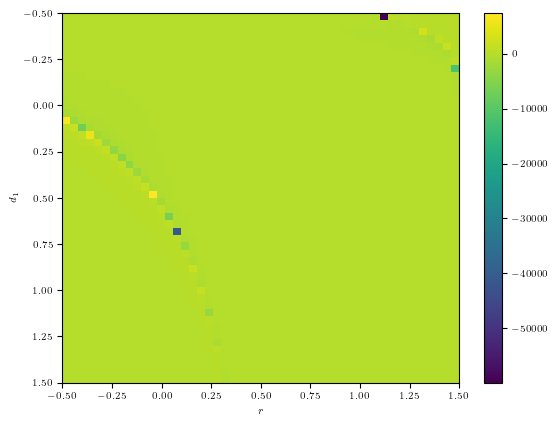

In [6]:
N = 50
h = 0.2
def max_der(R,d):
    items = []
    for i in range(2):
        for j in range(2):
            items.append(np.abs(dip_derivative_full(R,i,j,d,100)))
    return items[0]#max(items)
R = np.stack((np.linspace(0,1,N),np.ones(N)*h))
d1 = np.linspace(0,1,N)
d = np.array([np.sqrt(1/3),np.sqrt(2/3)])

V = np.zeros((N,N))
V_der = np.zeros((N,N))
for i in range(N):#
    for j in range(N):
        V[i,j] = dip_dip(R[:,i],np.array([d1[j],np.sqrt(1-d1[j]**2)]))
        V_der[i,j] = max_der(R[:,i],np.array([d1[j],np.sqrt(1-d1[j]**2)]))

fig, ax = plt.subplots(1,1)
im = ax.imshow(V_der/V,extent=(-0.5,1.5,1.5,-0.5),aspect='auto')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$d_1$')
plt.colorbar(im,ax=ax)
plt.show()

# fig, ax = plt.subplots(1,2)
# for i in range(N):#
#     ax[0].scatter(R[0,i],max_der(R[:,i],d)/dip_dip(R[:,i],d),color='0')
#     ax[1].scatter(R[0,i],dip_dip(R[:,i],d),color='0')
# plt.show()


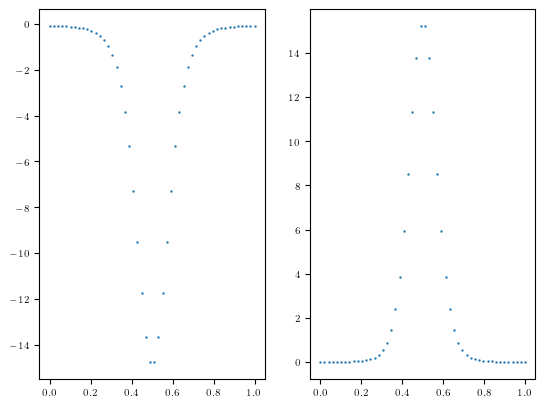

In [7]:
from scipy.optimize import minimize
def ratio(x,rx):
    h = x[0]
    d = np.array([np.sin(x[1]),np.cos(x[1])])
    R = np.array([rx,h])
    return -np.abs(dip_derivative_full(R,0,0,d,100)/dip_dip(R,d))
b0 =1.6
a = 2
freq = 1
h = 0.2
d = np.array([np.sqrt(1/3),np.sqrt(2/3)])
def time_traj(t):
    b = a/2+(b0-a/2)*np.cos(2*np.pi*freq*t)
    Delta = np.sin(2*np.pi*freq*t)
    return b, h, Delta
rx = np.linspace(0.5,4,N)
t = np.linspace(0,1,N)
V = np.zeros(N)
V2 = np.zeros(N)
V_der = np.zeros(N)
V_der2 = np.zeros(N)
Delta = np.zeros(N)
for i in range(N):
    rx[i], h, Delta[i] = time_traj(t[i])
    V_der[i] = dip_derivative_full(np.array([rx[i],h]),0,0,d,100)/70
    V[i] = dip_dip(np.array([rx[i],h]),d)
    V2[i] = dip_dip(np.array([rx[i]*4/3,0]),d)
    V_der2[i] = dip_derivative_full(np.array([rx[i]*4/3,0]),0,0,d,100)
    


fig, ax = plt.subplots(1,2)
# ax[0].scatter(rx,opt_h)
# ax[0].scatter(rx,opt_d1)
ax[0].scatter(t,V)
ax[1].scatter(t,V_der)
# fig2, ax2 = plt.subplots(1,2)
# ax2[0].scatter(rx,V)
# ax2[1].scatter(rx,V_der)
plt.show()





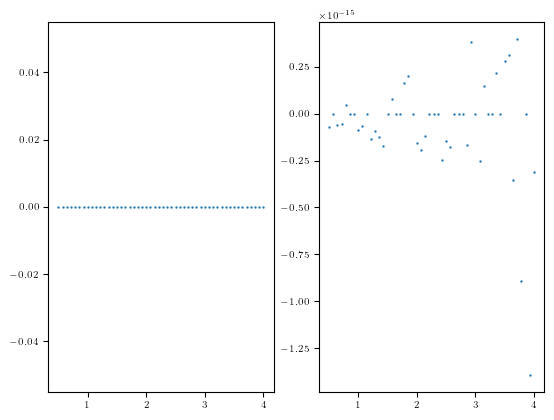

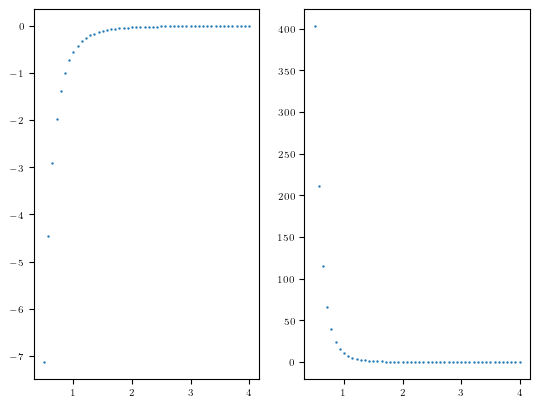

In [8]:
from scipy.optimize import minimize
def ratio(x,rx):
    h = x[0]
    d = np.array([np.sin(x[1]),np.cos(x[1])])
    R = np.array([rx,h])
    return -np.abs(dip_derivative_full(R,0,0,d,100)/dip_dip(R,d))

rx = np.linspace(0.5,4,N)
opt_h = np.ones(N)
opt_d1 = np.ones(N)
opt_ratio = np.zeros(N)
V = np.zeros(N)
V2 = np.zeros(N)
V_der = np.zeros(N)
V_der2 = np.zeros(N)
for i in range(N):
    res = minimize(ratio,x0=[opt_h[i-1],opt_d1[i-1]],args=(rx[i],),bounds=((0.15,1),(0,np.pi)))
    opt_h[i] = 0.2
    opt_d1[i] = np.arcsin(np.sqrt(1/3))
    opt_ratio[i] = res.fun
    V_der[i] = dip_derivative_full(np.array([rx[i],opt_h[i]]),0,0,np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]),100)
    V[i] = dip_dip(np.array([rx[i],opt_h[i]]),np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]))
    V2[i] = dip_dip(np.array([rx[i]*4/3,0]),np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]))
    V_der2[i] = dip_derivative_full(np.array([rx[i]*4/3,0]),0,0,np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]),100)


fig, ax = plt.subplots(1,2)
# ax[0].scatter(rx,opt_h)
# ax[0].scatter(rx,opt_d1)
ax[0].scatter(rx,V2/V)
ax[1].scatter(rx,V_der2/V_der)
fig2, ax2 = plt.subplots(1,2)
ax2[0].scatter(rx,V)
ax2[1].scatter(rx,V_der)
plt.show()





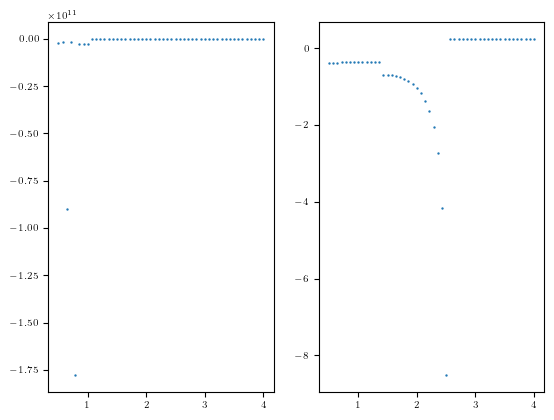

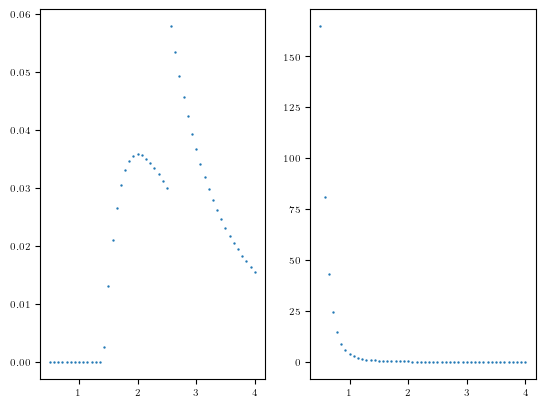

In [9]:
from scipy.optimize import minimize
def ratio(x,rx):
    h = x[0]
    d = np.array([np.sin(x[1]),np.cos(x[1])])
    R = np.array([rx,h])
    return -np.abs(dip_derivative_full(R,0,0,d,100)/dip_dip(R,d))

rx = np.linspace(0.5,4,N)
opt_h = np.ones(N)
opt_d1 = np.ones(N)
opt_ratio = np.zeros(N)
V = np.zeros(N)
V_der = np.zeros(N)
V_der2 = np.zeros(N)
for i in range(N):
    res = minimize(ratio,x0=[opt_h[i-1],opt_d1[i-1]],args=(rx[i],),bounds=((0.15,1),(0,np.pi)))
    opt_h[i] = res.x[0]
    opt_d1[i] = res.x[1]
    opt_ratio[i] = res.fun
    V_der[i] = dip_derivative_full(np.array([rx[i],opt_h[i]]),0,0,np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]),100)
    V[i] = dip_dip(np.array([rx[i],opt_h[i]]),np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]))
    V_der2[i] = dip_derivative_full(np.array([rx[i]*4/3,0]),0,0,np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]),100)


fig, ax = plt.subplots(1,2)
# ax[0].scatter(rx,opt_h)
# ax[0].scatter(rx,opt_d1)
ax[0].scatter(rx,opt_ratio)
ax[1].scatter(rx,V_der2/V_der)
fig2, ax2 = plt.subplots(1,2)
ax2[0].scatter(rx,V)
ax2[1].scatter(rx,V_der)
plt.show()





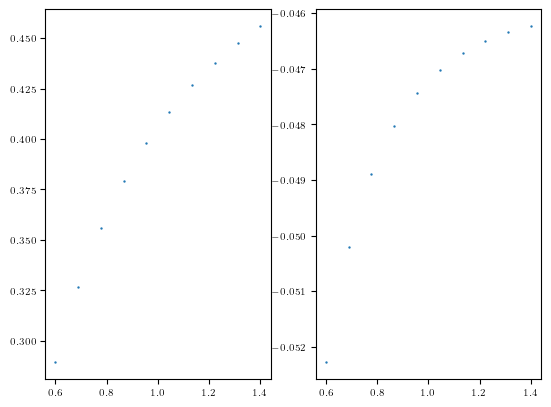

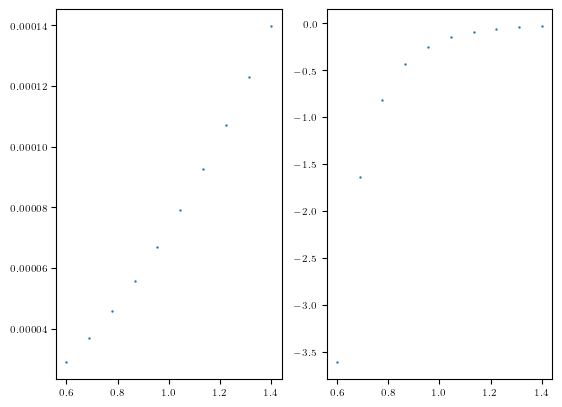

In [10]:
from scipy.optimize import root_scalar, minimize_scalar
def null(dx,R,sign):
    a = R[0]
    h = R[1]
    return 3*(a**2*dx**2+h**2*(1-dx**2)+sign*2*a*h*dx*np.sqrt(1-dx**2))-(a**2+h**2)
h = 0.35
N = 10
def ratio(h,rx):
    r = root_scalar(null,args=(np.array([rx,h]),1),bracket=(0,1))
    d = np.array([r.root,np.sqrt(1-r.root**2)])
    return np.abs(dip_derivative_full(np.array([rx,h]),0,0,d,100)/dip_derivative_full(np.array([rx*2,0]),0,0,d,100))
x = np.linspace(0.6,1.4,N)
opt_h = np.ones(N)*0.2
opt_d1 = np.ones(N)
opt_ratio = np.zeros(N)
V = np.zeros(N)
V2 = np.zeros(N)
V_der = np.zeros(N)
V_der2 = np.zeros(N)
for i in range(N):
    # res = minimize_scalar(ratio,args=(x[i],),bounds=((0.2,0.35)))
    opt_h[i] = 0.2#res.x
    r = root_scalar(null,args=(np.array([x[i],opt_h[i]]),1),bracket=(0,1))
    # r2 = root_scalar(null,args=(np.array([x[i],h]),-1),bracket=(0,1))
    opt_d1[i] = r.root
    V[i] = dip_dip(np.array([4*3*x[i],0]),np.array([opt_d1[i],np.sqrt(1-opt_d1[i]**2)]))
   
    V_der[i] = dip_derivative_full(np.array([x[i],opt_h[i]]),0,0,np.array([opt_d1[i],np.sqrt(1-opt_d1[i]**2)]),100)
    V_der2[i] = dip_derivative_full(np.array([x[i]*2,0]),0,0,np.array([opt_d1[i],np.sqrt(1-opt_d1[i]**2)]),100)

fig, ax = plt.subplots(1,2)
# ax[0].scatter(x,opt_h)
ax[0].scatter(x,opt_d1)
# ax[0].scatter(x,opt_ratio)
ax[1].scatter(x,V_der2/V_der)
fig2, ax2 = plt.subplots(1,2)
ax2[0].scatter(x,V/V_der)
ax2[1].scatter(x,V_der2)
plt.show()



In [11]:
from scipy import constants
constants.e**2/(4*np.pi*constants.epsilon_0)/133/constants.u*5162**2*(5e-11)**2/10**(-25)/50000, constants.hbar/constants.k*50000*2*np.pi


(13917.699617451763, 2.3996215366831105e-06)

In [12]:
1/(np.exp(0.5)-1)



np.float64(1.5414940825367982)

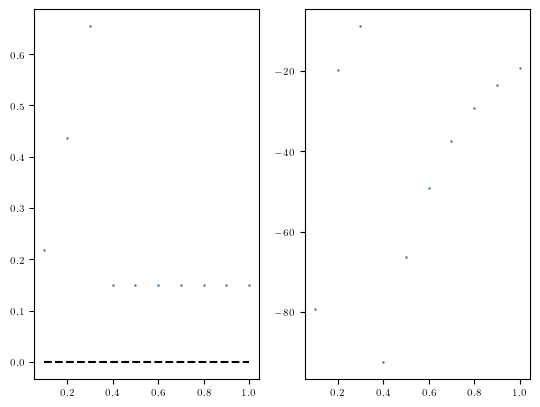

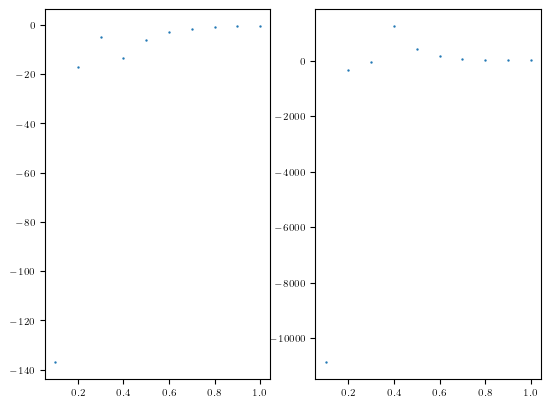

In [13]:
from scipy.optimize import minimize, minimize_scalar
def ratio(x,rx):
    h = x
    d = np.array([np.sqrt(1/3),np.sqrt(2/3)])
    R = np.array([rx,h])
    return -np.abs(dip_derivative_full(R,0,0,d,100)/dip_dip(R,d))

rx = np.linspace(0.1,1,N)
opt_h = np.ones(N)
opt_d1 = np.zeros(N)
opt_ratio = np.zeros(N)
V = np.zeros(N)
V_der = np.zeros(N)
for i in range(N):
    res = minimize_scalar(ratio,args=(rx[i],),bounds=(0.15,1))
    opt_h[i] = res.x
    # opt_d1[i] = res.x[1]
    opt_ratio[i] = res.fun
    V_der[i] = dip_derivative_full(np.array([rx[i],opt_h[i]]),0,0,np.array([np.sqrt(1/3),np.sqrt(2/3)]),100)
    V[i] = dip_dip(np.array([rx[i],opt_h[i]]),np.array([np.sqrt(1/3),np.sqrt(2/3)]))


fig, ax = plt.subplots(1,2)
ax[0].scatter(rx,opt_h)
ax[0].hlines(0,rx[0],rx[-1],color='0',linestyle='dashed')
# ax[0].scatter(rx,opt_d1)
ax[1].scatter(rx,np.where(opt_ratio<-1e12,0,opt_ratio))
fig2, ax2 = plt.subplots(1,2)
ax2[0].scatter(rx,V)
ax2[1].scatter(rx,V_der)
plt.show()





In [14]:
ind = [0,1,3]
A = np.arange(16).reshape(4,4)
indices = [[],[]]
for i in ind:
    for j in ind:
        indices[0].append(i)
        indices[1].append(j)
np.array(indices)
print(A)
A = A[ind,:]
print(A)
A[:,ind]


[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [12 13 14 15]]


array([[ 0,  1,  3],
       [ 4,  5,  7],
       [12, 13, 15]])

In [65]:
from qutip import enr_destroy, enr_fock, enr_identity, enr_state_dictionaries, tensor, Qobj, enr_thermal_dm
from scipy.special import factorial, binom
from scipy.sparse import coo_matrix, csr_matrix


def add_one(state,ex):
    
    if np.sum(state)==ex:
        state[-1] = 0
        state[:-1] = add_one(state[:-1],ex)
    else:
        state[-1] += 1
    return state



def project_indices(excitations,chain_length):
    state = np.zeros(chain_length,dtype=np.int16)
    indices = []
    if np.sum(state)==excitations:
        return 0
    for i in range(1,int(binom(chain_length+excitations,excitations))):
        state = add_one(state,excitations)
        if np.sum(state)==excitations:
            # print(i, state)
            indices.append(i)
    # discard = int(factorial(excitations+chain_length-1)//(factorial(excitations-1)*factorial(chain_length)))
    # return discard
    return indices

def projector(indices,*operators):
        # discard = int(factorial(excitations+chain_length-1)//(factorial(excitations-1)*factorial(chain_length)))
        new_qops = []
        for operator in operators:
            # if type(operator)==complex:
            #     return enr_destroy([excit_phonons+1]*chain_length,excit_phonons)
            operator_full = operator.to("CSR").data_as("csr_matrix")
            operator_new = operator_full[indices,:][:,indices]
            # operator_new = operator_full[indices:,indices:]
            # .tocoo()
            # data, coords = operator_full.data, operator_full.coords
            # coords = np.stack((coords[0]-discard,coords[1]-discard))
            # # print(coords)
            # # print(discard)
            # # coords -= discard
            # operator_new = coo_matrix((data,coords),shape=[operator_full.shape[0]-int(discard)]*2)#.tocsr()
            # print(type(operator_new))
            if len(operators)==1:
                return Qobj(operator_new)
            new_qops.append(Qobj(operator_new))
        return new_qops

def project_vec(indices,*operators):
        # discard = int(factorial(excitations+chain_length-1)//(factorial(excitations-1)*factorial(chain_length)))
        new_qops = []
        for operator in operators:
            operator_full = operator.full()[indices]#operator.to("CSR").data_as("csr_matrix")
            # operator_new = operator_full[indices]
            # print(operator_new)
            if len(operators)==1:
                return Qobj(operator_full)
            new_qops.append(Qobj(operator_full))
        return new_qops

def operators_zero(chain_length,excit_spin=1):
   
    indices_spin = project_indices(excit_spin,chain_length)
    
    dims_spin = [excit_spin+1]*chain_length
    
    destroy_spin = enr_destroy(dims_spin,excitations=excit_spin)
   
    identity_spin = projector(indices_spin,enr_identity(dims_spin,excitations=excit_spin))
    
    project_spin =[]
    spin_flips = []
    
    
    
    for i in range(len(destroy_spin)):
        
        project_spin.append(projector(indices_spin,destroy_spin[i].dag()*destroy_spin[i]))
        
       
       
        if i<len(destroy_spin)-1:
            op_sp_flip = destroy_spin[i].dag()*destroy_spin[i+1]
            spin_flips.append(projector(indices_spin,op_sp_flip))
     
    phonon_flips, project_phonon, identity_phonon= [0]*3
    return phonon_flips, spin_flips, project_phonon, project_spin, identity_phonon ,identity_spin, project_spin

def operators(chain_length,excit_phonons,excit_spin=1):
    if excit_phonons==0:
        return operators_zero(chain_length,excit_spin)
    indices = project_indices(excit_phonons,chain_length)
    indices_spin = project_indices(excit_spin,chain_length)
    dims_phonon = [excit_phonons+1]*chain_length
    dims_spin = [excit_spin+1]*chain_length
    destroy_phonon = enr_destroy(dims_phonon,excitations=excit_phonons)
    destroy_spin = enr_destroy(dims_spin,excitations=excit_spin)
    identity_phonon = projector(indices,enr_identity(dims_phonon,excitations=excit_phonons))
    identity_spin = projector(indices_spin,enr_identity(dims_spin,excitations=excit_spin))
    project_phonon = []
    project_spin =[]
    spin_flips = []
    phonon_flips = []
    eval_projector_spin = []
    eval_projector_phonon = []
    for i in range(len(destroy_phonon)):
        project_phonon.append(projector(indices,destroy_phonon[i].dag()*destroy_phonon[i]))
        project_spin.append(projector(indices_spin,destroy_spin[i].dag()*destroy_spin[i]))
        eval_projector_spin.append(tensor(project_spin[i],identity_phonon))
        # print(project_phonon[i])
        eval_projector_phonon.append(tensor(identity_spin,project_phonon[i]))
        if i<len(destroy_phonon)-1:
            op_sp_flip = destroy_spin[i].dag()*destroy_spin[i+1]
            op_ph_flip = destroy_phonon[i].dag()*destroy_phonon[i+1]
            spin_flips.append(projector(indices_spin,op_sp_flip))
            phonon_flips.append(projector(indices,op_ph_flip))

    return phonon_flips, spin_flips, project_phonon, project_spin, identity_phonon ,identity_spin, eval_projector_spin+eval_projector_phonon#[::-1]


def operators_full(chain_length,excit_phonons,excit_spin=1):
    dims_phonon = [excit_phonons+1]*chain_length
    dims_spin = [excit_spin+1]*chain_length
    destroy_phonon = enr_destroy(dims_phonon,excitations=excit_phonons)
    destroy_spin = enr_destroy(dims_spin,excitations=excit_spin)
    identity_phonon = enr_identity(dims_phonon,excitations=excit_phonons)
    identity_spin = enr_identity(dims_spin,excitations=excit_spin)
    project_phonon = []
    project_spin =[]
    spin_flips = []
    phonon_flips = []
    eval_projector_spin = []
    eval_projector_phonon = []
    for i in range(len(destroy_phonon)):
        project_phonon.append(destroy_phonon[i].dag()*destroy_phonon[i])
        project_spin.append(destroy_spin[i].dag()*destroy_spin[i])
        eval_projector_spin.append(tensor(project_spin[i],identity_phonon))
        eval_projector_phonon.append(tensor(identity_spin,project_phonon[i]))
        if i<len(destroy_phonon)-1:
            op_sp_flip = destroy_spin[i].dag()*destroy_spin[i+1]
            op_ph_flip = destroy_phonon[i].dag()*destroy_phonon[i+1]
            spin_flips.append(op_sp_flip)
            phonon_flips.append(op_ph_flip)

    return phonon_flips, spin_flips, project_phonon, project_spin, identity_phonon ,identity_spin, eval_projector_spin+eval_projector_phonon


class system():
    def __init__(self,chain_length,excit_phonons,interaction_sp=dip_dip,interaction_spph=dip_derivative_full,excit_spin=1,a=1,d=np.array([np.sqrt(1/3),np.sqrt(2/3)]),ph_scale=1/50,sp_scale=1,full=True):
        self.chain_length = chain_length
        self.excit_phonons = excit_phonons
        self.excit_spin = excit_spin
        self.interaction_sp = interaction_sp
        self.interaction_spph = interaction_spph
        self.a = a
        self.d = d
        self.ph_scale = ph_scale
        self.sp_scale = sp_scale
        if full:
            self.phonon_flips, self.spin_flips, self.project_phonon, self.project_spin, self.identity_phonon, self.identity_spin, self.projectors_eval = operators_full(chain_length,excit_phonons,excit_spin)
        else:
            self.phonon_flips, self.spin_flips, self.project_phonon, self.project_spin, self.identity_phonon, self.identity_spin, self.projectors_eval = operators(chain_length,excit_phonons,excit_spin)
        self.eval_functions = []
        for i in range(len(self.projectors_eval)):
            self.eval_functions.append(lambda t,rho, i=i : (self.projectors_eval[i]*rho).tr())

            
    param_trajectory = None
    
    # def projector(self,operator):
    #     discard = factorial(self.excit_spin+self.chain_length-2)//(factorial(self.excit_spin-1)*factorial(self.chain_length-1))
    #     operator_full = operator.to("CSR").data_as("csr_matrix").tocoo()
    #     data, coords = operator_full.data, operator_full.coords
    #     coords = np.stack((coords[0]-discard,coords[1]-discard))
    #     # print(coords)
    #     # print(discard)
    #     # coords -= discard
    #     operator_new = coo_matrix((data,coords),shape=[operator_full.shape[0]-int(discard)]*2)#.tocsr()
    #     # print(type(operator_new))
    #     return Qobj(operator_new)
    
    def Hamiltonian_spin_only(self,Delta,interaction1,interaction2):
        Ham_spin = 0
        # print(interaction1,interaction2,"spin")
        for i in range(self.chain_length//2):
            Ham_spin += Delta * self.project_spin[2*i]- Delta * self.project_spin[2*i+1]
            op = interaction1* self.spin_flips[2*i]
            if  i<self.chain_length//2+self.chain_length%2-1:
                op2 = interaction2* self.spin_flips[2*i+1]
                Ham_spin += op2 + op2.dag()
            Ham_spin += op+op.dag()
        # return 0
        return Ham_spin

    def Hamiltonian_spin(self,Delta,interaction1,interaction2):
        Ham_spin = 0
        # print(interaction1,interaction2,"spin")
        for i in range(self.chain_length//2):
            Ham_spin += Delta * tensor(self.project_spin[2*i],self.identity_phonon) - Delta * tensor(self.project_spin[2*i+1],self.identity_phonon)
            op = interaction1* tensor(self.spin_flips[2*i],self.identity_phonon)
            if  i<self.chain_length//2+self.chain_length%2-1:
                op2 = interaction2* tensor(self.spin_flips[2*i+1],self.identity_phonon)
                Ham_spin += op2 + op2.dag()
            Ham_spin += op+op.dag()
        # return 0
        return Ham_spin

    def Hamiltonian_spin_phonon(self,interaction1,interaction2):
        Ham_ps= 0
        # print(interaction1,interaction2,"phonon")
        for i in range(self.chain_length//2):
            op_ph = interaction1 * (self.phonon_flips[2*i]+ self.phonon_flips[2*i].dag()- self.project_phonon[2*i]- self.project_phonon[2*i+1])
            
            Ham_ps += tensor(self.spin_flips[2*i],op_ph)

            if i<self.chain_length//2+self.chain_length%2-1:

                op_ph2 = interaction2 * (self.phonon_flips[2*i+1]+ self.phonon_flips[2*i+1].dag()- self.project_phonon[2*i+1]- self.project_phonon[2*(i+1)]) 
                
                Ham_ps += tensor(self.spin_flips[2*i+1],op_ph2)

        return Ham_ps + Ham_ps.dag()
    
    def Hamiltonian_phonon_only(self,b,h):
        latticeA = np.array([[0,0],[self.a,0]])
        latticeB = np.array([b,h])
        dist1 = latticeA[0]-latticeB
        dist2 = latticeA[1]-latticeB
        phonon_direction = 0
        inter_ph1 = dip_derivative_full(dist1,phonon_direction,phonon_direction,self.d)
        inter_ph2 = dip_derivative_full(dist2,phonon_direction,phonon_direction,self.d)
        Ham_ps= 0
        # print(interaction1,interaction2,"phonon")
        for i in range(self.chain_length//2):
            op_ph =  inter_ph1 *(self.phonon_flips[2*i]+ self.phonon_flips[2*i].dag()- self.project_phonon[2*i]- self.project_phonon[2*i+1])
            # op_ph =  
            Ham_ps += op_ph
            break
            if i<self.chain_length//2+self.chain_length%2-1:

                op_ph2 = inter_ph2 * (self.phonon_flips[2*i+1]+ self.phonon_flips[2*i+1].dag()- self.project_phonon[2*i+1]- self.project_phonon[2*(i+1)]) 
                
                Ham_ps += op_ph2

        return Ham_ps #+ Ham_ps.dag()
         
    def Hamiltonian_spin_time(self,t):
        b, h, Delta = self.param_trajectory(t)
        latticeA = np.array([[0,0],[self.a,0]])
        latticeB = np.array([b,h])
        dist1 = latticeA[0]-latticeB
        dist2 = latticeA[1]-latticeB
        inter1 = dip_dip(dist1,self.d)
        inter2 = dip_dip(dist2,self.d)
        
        # return 0
        return self.Hamiltonian_spin_only(Delta,inter1,inter2) 

    def Hamiltonian_time(self,t):
        b, h, Delta = self.param_trajectory(t)
        latticeA = np.array([[0,0],[self.a,0]])
        latticeB = np.array([b,h])
        dist1 = latticeA[0]-latticeB
        dist2 = latticeA[1]-latticeB
        inter1 = dip_dip(dist1,self.d)
        inter2 = dip_dip(dist2,self.d)
        phonon_direction = 0
        inter_ph1 = dip_derivative_full(dist1,phonon_direction,phonon_direction,self.d)
        inter_ph2 = dip_derivative_full(dist2,phonon_direction,phonon_direction,self.d)
        # 
        return  self.sp_scale * self.Hamiltonian_spin(Delta,inter1,inter2) +self.ph_scale * self.Hamiltonian_spin_phonon(inter_ph1,inter_ph2)
    
    
    def Hamiltonian(self,b,h,Delta=0):
        latticeA = np.array([[0,0],[self.a,0]])
        latticeB = np.array([b,h])
        dist1 = latticeA[0]-latticeB
        dist2 = latticeA[1]-latticeB
        inter1 = dip_dip(dist1,self.d)
        inter2 = dip_dip(dist2,self.d)
        phonon_direction = 0
        inter_ph1 = dip_derivative_full(dist1,phonon_direction,phonon_direction,self.d)
        inter_ph2 = dip_derivative_full(dist2,phonon_direction,phonon_direction,self.d)
        # 
        # print(inter_ph1,inter_ph2,self.ph_scale,"phonon")
        # inter_ph1 = 1
        # inter_ph2 = 1
        return self.sp_scale * self.Hamiltonian_spin(Delta,inter1,inter2) +self.ph_scale *  self.Hamiltonian_spin_phonon(inter_ph1,inter_ph2)
    
    def Hamiltonian_spinner(self,b,h,Delta=0):
        latticeA = np.array([[0,0],[self.a,0]])
        latticeB = np.array([b,h])
        dist1 = latticeA[0]-latticeB
        dist2 = latticeA[1]-latticeB
        inter1 = dip_dip(dist1,self.d)
        inter2 = dip_dip(dist2,self.d)
        
        return self.Hamiltonian_spin_only(Delta,inter1,inter2) 






In [16]:
# chain_length = 3
# excit_phonons = 0
# # S = system(chain_length,excit_phonons,full=False)
# tensor(enr_destroy([3],2),enr_identity([1],0))
enr_identity([0],0), enr_destroy([3],2)
# # type(enr_destroy([2]*3,excitations=0)[0].dag()*enr_destroy([2]*3,excitations=0)[0])

(Quantum object: dims=[[0], [0]], shape=(1, 1), type='scalar', dtype=Dia
 Qobj data =
 [[1.]],
 [Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=CSR, isherm=False
  Qobj data =
  [[0.         1.         0.        ]
   [0.         0.         1.41421356]
   [0.         0.         0.        ]]])

In [17]:
def photon_Hamiltonian(b,h,a,chain_length,interaction,Delta,d):
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*a
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*a + b * np.array([1,0])+h*np.array([0,1])
    dmat = np.zeros((chain_length,chain_length))
    ind = np.arange(chain_length,dtype=np.int16)
    inter_1 = interaction(latticeB[:,0]-latticeA[:,0],d)
    inter_2 = interaction(latticeB[:,0]-latticeA[:,1],d)
    dmat[ind[:-1:2],ind[1::2]]= inter_1
    dmat[ind[1::2],ind[:-1:2]]= inter_1
    dmat[ind[1:-1:2],ind[2::2]] = inter_2
    dmat[ind[2::2],ind[1:-1:2]] = inter_2
    dmat[ind[::2],ind[::2]] = Delta
    dmat[ind[1::2],ind[1::2]]= -Delta
    # print(inter_1,inter_2,b)
    return dmat#



In [18]:
ex = 2
chain_length = 2
dims = [ex+1]*chain_length
enr_state_dictionaries(dims,excitations=ex)

state = np.zeros(chain_length,dtype=np.int16)
states = [state.copy()]
def add_one(state,ex):
    
    if np.sum(state)==ex:
        state[-1] = 0
        state[:-1] = add_one(state[:-1],ex)
    else:
        state[-1] += 1
    return state

for i in range(int(binom(chain_length+ex,ex))-1):
    state = add_one(state,ex)
    if np.sum(state)==ex:
        print(i+1, state)
    states.append(state.copy())
states

2 [0 2]
4 [1 1]
5 [2 0]


[array([0, 0], dtype=int16),
 array([0, 1], dtype=int16),
 array([0, 2], dtype=int16),
 array([1, 0], dtype=int16),
 array([1, 1], dtype=int16),
 array([2, 0], dtype=int16)]

In [19]:
from qutip import tensor, basis, destroy, create, qeye, sesolve, sigmap, sigmam, fidelity, qzero, expect, ptrace
chain_length = 4
boson_number = 3


unity_spin = tensor([qeye(2)]*chain_length)
annihilation_phonon = []
phonon_projectors = []
for i in range(chain_length):
    op_list = []
    op_proj = []
    for j in range(chain_length):
        if i == j:
            op_list.append(destroy(boson_number))
            op_proj.append(create(boson_number)*destroy(boson_number))
        else:
            op_list.append(qeye(boson_number))
            op_proj.append(qeye(boson_number))
    annihilation_phonon.append(tensor(op_list))
    phonon_projectors.append(tensor([qeye(2)]*chain_length+op_proj))
unity_phonon = tensor([qeye(boson_number) for i in range(chain_length)])
sigmas_p = []
sigmas_m = []
onsite_projectors_spin = []
projectors_eval = []
for i in range(chain_length):
    op_list = []
    op_list_id = []
    for j in range(chain_length):
        if i == j:
            op_list.append(sigmap())
            op_list_id.append(sigmap()*sigmam())
        else:
            op_list.append(qeye(2))
            op_list_id.append(qeye(2))
    sigmas_p.append(tensor(op_list))
    sigmas_m.append(tensor(op_list).dag())
    onsite_projectors_spin.append(tensor(op_list_id))
    projectors_eval.append(tensor(tensor(op_list_id),unity_phonon))
projectors_eval = projectors_eval + phonon_projectors

def Hamiltonian_1Dph(Delta,b,h,a,phonon_direction,d,ph_scale):
    latticeA = np.array([[0,0],[a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeA[0]-latticeB
    dist2 = latticeA[1]-latticeB
    inter1 = dip_dip(dist1,d)
    inter2 = dip_dip(dist2,d)
    inter_ph1 = dip_derivative_full(dist1,phonon_direction,phonon_direction,d)
    inter_ph2 = dip_derivative_full(dist2,phonon_direction,phonon_direction,d)
    
    return Hamiltonian_spin_only(Delta,inter1,inter2) + ph_scale * Hamiltonian_spin_phonon(inter_ph1,inter_ph2)


def Hamiltonian_spin_only(Delta,interaction1,interaction2):
    Ham_spin = 0
    # print(interaction1,interaction2,"spin")
    for i in range(chain_length//2):
        Ham_spin += Delta * tensor(onsite_projectors_spin[2*i],unity_phonon) - Delta * tensor(onsite_projectors_spin[2*i+1],unity_phonon)
        op = interaction1* tensor(sigmas_p[i*2],unity_phonon)* tensor(sigmas_m[i*2+1],unity_phonon)
        if  i<chain_length//2+chain_length%2-1:
            op2 = interaction2* tensor(sigmas_p[i*2+1],unity_phonon) * tensor(sigmas_m[(i+1)*2],unity_phonon)
            Ham_spin += op2 + op2.dag()
        Ham_spin += op+op.dag()
    # return 0
    return Ham_spin

def Hamiltonian_spin_phonon(interaction1,interaction2):
    Ham_ps= 0
    # print(interaction1,interaction2,"phonon")
    for i in range(chain_length//2):
        op_ph = interaction1 * (annihilation_phonon[2*i].dag()*annihilation_phonon[2*i+1] + annihilation_phonon[2*i+1].dag()*annihilation_phonon[2*i]-annihilation_phonon[2*i].dag()*annihilation_phonon[2*i]-annihilation_phonon[2*i+1].dag()*annihilation_phonon[2*i+1])
        Ham_ps += tensor(sigmas_p[i*2]*sigmas_m[i*2+1],op_ph)
        # Ham_ps += tensor(sigmas_p[i*2+1]*sigmas_m[i*2],op_ph)
        # Ham_ps += tensor(unity_spin,op_ph)
        if i<chain_length//2+chain_length%2-1:
            op_ph2 = interaction2 * (annihilation_phonon[2*i+1].dag()*annihilation_phonon[2*(i+1)] + annihilation_phonon[2*(i+1)].dag()*annihilation_phonon[2*i+1]-annihilation_phonon[2*i+1].dag()*annihilation_phonon[2*i+1]-annihilation_phonon[2*(i+1)].dag()*annihilation_phonon[2*(i+1)])
            Ham_ps += tensor(sigmas_p[i*2+1]*sigmas_m[2*(i+1)],op_ph2)
            # Ham_ps += tensor(sigmas_p[2*(i+1)]*sigmas_m[i*2+1],op_ph2)
            # Ham_ps += tensor(unity_spin,op_ph2)
    # return 0
    return Ham_ps + Ham_ps.dag()
         

# H =Hamiltonian_1Dph(1,a/2,0,a,0,np.array([0,1]),1)


In [20]:
phonon0 = tensor([basis(boson_number,0) for i in range(chain_length)])
(annihilation_phonon[0].dag()**2*phonon0).full().T

array([[0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
        0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
        0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
        0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
        0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
        0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
        0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
        0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
        0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
        0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
        0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
        0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
        0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
        0.        +0.j, 0.        +0.j, 1.41421356+0.j, 0.      

In [21]:
from qutip import tensor, basis, destroy, create, qeye, sesolve, sigmap, sigmam, fidelity, qzero, expect, ptrace


def full_operators(chain_length,boson_number):
    unity_spin = tensor([qeye(2)]*chain_length)
    annihilation_phonon = []
    phonon_projectors = []
    for i in range(chain_length):
        op_list = []
        op_proj = []
        for j in range(chain_length):
            if i == j:
                op_list.append(destroy(boson_number))
                op_proj.append(create(boson_number)*destroy(boson_number))
            else:
                op_list.append(qeye(boson_number))
                op_proj.append(qeye(boson_number))
        annihilation_phonon.append(tensor(op_list))
        phonon_projectors.append(tensor([qeye(2)]*chain_length+op_proj))
    unity_phonon = tensor([qeye(boson_number) for i in range(chain_length)])
    sigmas_p = []
    sigmas_m = []
    onsite_projectors_spin = []
    projectors_eval = []
    for i in range(chain_length):
        op_list = []
        op_list_id = []
        for j in range(chain_length):
            if i == j:
                op_list.append(sigmap())
                op_list_id.append(sigmap()*sigmam())
            else:
                op_list.append(qeye(2))
                op_list_id.append(qeye(2))
        sigmas_p.append(tensor(op_list))
        sigmas_m.append(tensor(op_list).dag())
        onsite_projectors_spin.append(tensor(op_list_id))
        projectors_eval.append(tensor(tensor(op_list_id),unity_phonon))
    projectors_eval = projectors_eval + phonon_projectors
    return annihilation_phonon, sigmas_m, sigmas_p, phonon_projectors, onsite_projectors_spin, unity_phonon, unity_spin, projectors_eval

class full_dynamics():
    def __init__(self,chain_length,boson_number,a=1,d=np.array([np.sqrt(1/3),np.sqrt(2/3)]),ph_scale=1/50):
        self.chain_length = chain_length
        self.boson_number = boson_number
        self.a = a
        self.d = d
        self.ph_scale = ph_scale
        self.annihilation_phonon, self.sigmas_m, self.sigmas_p, self.phonon_projectors, self.onsite_projectors_spin, self.unity_phonon, self.unity_spin, self.projectors_eval = full_operators(chain_length,boson_number=boson_number)

    
    
        self.latticeA = np.zeros((2,chain_length//2+chain_length%2))
        self.latticeB = np.zeros((2,chain_length//2))
        for n in range(self.latticeA.shape[1]):
            self.latticeA[:,n] = n*np.array([1,0])*a
        for n in range(self.latticeB.shape[1]):
            self.latticeB[:,n] = n*np.array([1,0])*a + a/2*np.array([1,0])
    
    def Hamiltonian_1Dph(self,Delta,b,h,phonon_direction=0):
        latticeA = np.array([[0,0],[self.a,0]])
        latticeB = np.array([b,h])
        dist1 = latticeA[0]-latticeB
        dist2 = latticeA[1]-latticeB
        inter1 = dip_dip(dist1,self.d)
        inter2 = dip_dip(dist2,self.d)
        inter_ph1 = dip_derivative_full(dist1,phonon_direction,phonon_direction,self.d)
        inter_ph2 = dip_derivative_full(dist2,phonon_direction,phonon_direction,self.d)
        # self.Hamiltonian_spin_only(Delta,inter1,inter2) + self.ph_scale * 
        # inter_ph1 = 1
        # inter_ph2 = 1
        return self.Hamiltonian_spin_phonon(inter_ph1,inter_ph2)


    def Hamiltonian_spin_only(self,Delta,interaction1,interaction2):
        Ham_spin = 0
        # print(interaction1,interaction2,"spin")
        for i in range(self.chain_length//2):
            Ham_spin += Delta * tensor(self.onsite_projectors_spin[2*i],self.unity_phonon) - Delta * tensor(self.onsite_projectors_spin[2*i+1],self.unity_phonon)
            op = interaction1* tensor(self.sigmas_p[i*2],self.unity_phonon)* tensor(self.sigmas_m[i*2+1],self.unity_phonon)
            if  i<self.chain_length//2+self.chain_length%2-1:
                op2 = interaction2* tensor(self.sigmas_p[i*2+1],self.unity_phonon) * tensor(self.sigmas_m[(i+1)*2],self.unity_phonon)
                Ham_spin += op2 + op2.dag()
            Ham_spin += op+op.dag()
        # return 0
        return Ham_spin

    def Hamiltonian_spin_phonon(self, interaction1, interaction2):
        Ham_ps= 0
        # print(interaction1,interaction2,"phonon")
        for i in range(self.chain_length//2):
            op_ph = interaction1 * (self.annihilation_phonon[2*i].dag()*self.annihilation_phonon[2*i+1] + self.annihilation_phonon[2*i+1].dag()*self.annihilation_phonon[2*i]-self.annihilation_phonon[2*i].dag()*self.annihilation_phonon[2*i]-self.annihilation_phonon[2*i+1].dag()*self.annihilation_phonon[2*i+1])
            Ham_ps += tensor(self.sigmas_p[i*2]*self.sigmas_m[i*2+1],op_ph)
            # Ham_ps += tensor(self.sigmas_p[i*2+1]*self.sigmas_m[i*2],op_ph)
            # Ham_ps += tensor(self.unity_spin,op_ph)
            if i<self.chain_length//2+self.chain_length%2-1:
                op_ph2 = interaction2 * (self.annihilation_phonon[2*i+1].dag()*self.annihilation_phonon[2*(i+1)] + self.annihilation_phonon[2*(i+1)].dag()*self.annihilation_phonon[2*i+1]-self.annihilation_phonon[2*i+1].dag()*self.annihilation_phonon[2*i+1]-self.annihilation_phonon[2*(i+1)].dag()*self.annihilation_phonon[2*(i+1)])
                Ham_ps += tensor(self.sigmas_p[i*2+1]*self.sigmas_m[2*(i+1)],op_ph2)
                # Ham_ps += tensor(self.sigmas_p[2*(i+1)]*self.sigmas_m[i*2+1],op_ph2)
                # Ham_ps += tensor(self.unity_spin,op_ph2)
        # return 0
        return Ham_ps + Ham_ps.dag()
         

# H =Hamiltonian_1Dph(1,a/2,0,a,0,np.array([0,1]),1)


In [22]:
S = system(3,0,full=False)

# projector(1,3,enr_destroy([2]*3,excitations=1)[0].dag()*enr_destroy([2]*3,excitations=1)[1])

In [23]:
operator = enr_destroy([2]*3,excitations=1)[0]
operator_full = operator.to("CSR").data_as("csr_matrix").tocoo()
from qutip import Qobj
operator, Qobj(operator_full)

(Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=False
 Qobj data =
 [[0. 0. 0. 1.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]],
 Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=CSR, isherm=False
 Qobj data =
 [[0. 0. 0. 1.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]])

In [49]:
from random import random
a =2
def generate_random_initial():
    b = a*random()
    h = 0.6*random()
    r_vec1 = np.zeros((chain_length,chain_length))
    # r_vec2 = np.zeros(chain_length)
    for i in range(chain_length):
        for j in range(chain_length):
            r_vec1[i,j]= random()
        # r_vec2[i] = random()
    r_vec1 /= np.linalg.norm(r_vec1)
    # r_vec2 /= np.linalg.norm(r_vec2)
    return b, h, r_vec1#, r_vec2

b, h, eig0 = generate_random_initial()
eig0 = np.array([random() for i in range(chain_length)])
eig0 /= np.linalg.norm(eig0)

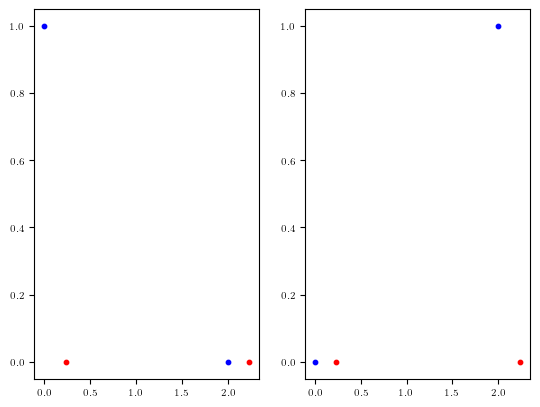

(256, 256)


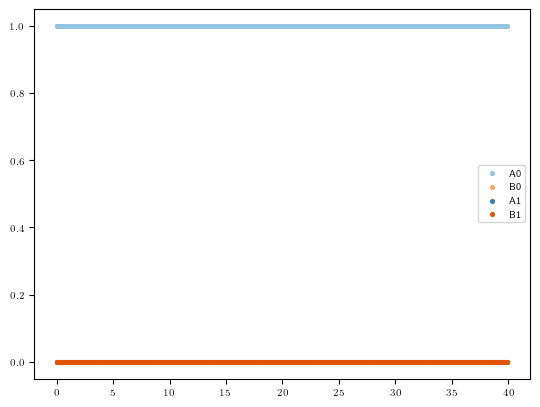

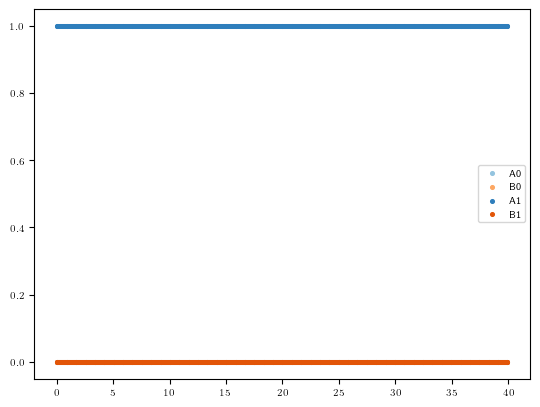

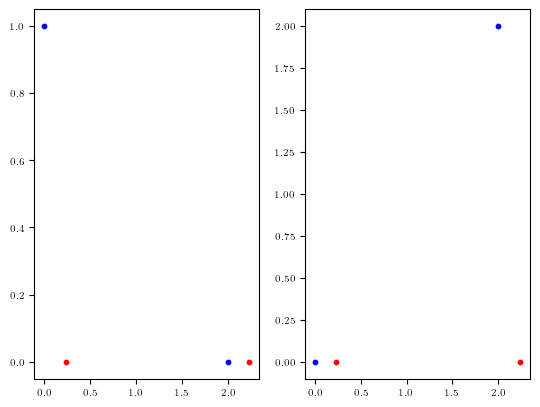

(1296, 1296)


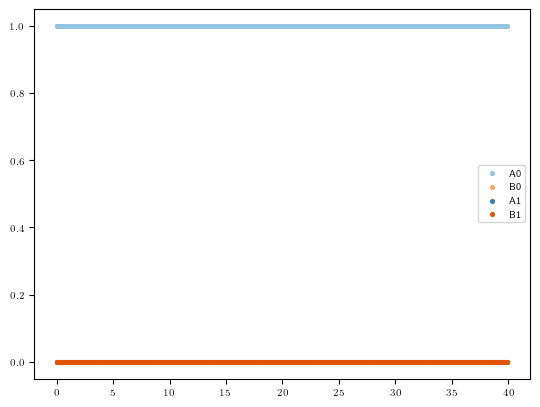

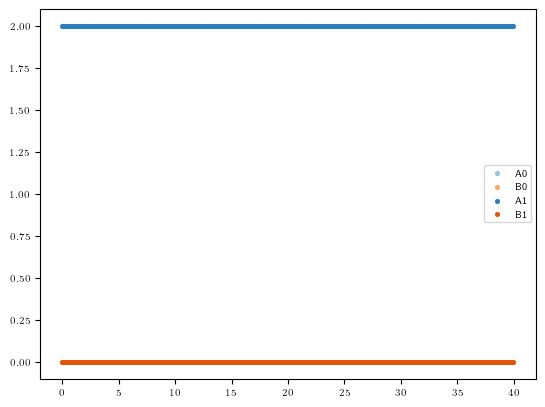

In [25]:
latticeA = np.zeros((2,chain_length//2+chain_length%2))
latticeB = np.zeros((2,chain_length//2))
atol = 1e-16
a = 2
for n in range(latticeA.shape[1]):
    latticeA[:,n] = n*np.array([1,0])*a
for n in range(latticeB.shape[1]):
    latticeB[:,n] = n*np.array([1,0])*a + b*np.array([1,0])+h*np.array([0,1])
   

import matplotlib.cm as cm
orange = cm.Oranges
blue = cm.Blues
# d = np.array([np.sqrt(1/3),np.sqrt(2/3)])
d = np.array([0,1])


tsteps = 500
dt = 40/tsteps

# tsteps = 800
# dt = 400/tsteps
t = np.arange(tsteps)*dt
freq = 1/t[-1]

def thermal_phonon_generator(excitations,chain_length):
    state = np.zeros(chain_length,dtype=np.int16)
    states = []
    if np.sum(state)==excitations:
        return 0
    for i in range(1,int(binom(chain_length+excitations,excitations))):
        state = add_one(state,excitations)
        if np.sum(state)==excitations:
            states.append(state.copy())
   
    return states
for l in range(1,3):
    boson_number = l+1
    Sys_full = full_dynamics(chain_length,boson_number=boson_number,a=a,d=d,ph_scale=10)
    def Hamiltonian_spph_for_tevol(t):
        # b = a/2+(b0-a/2)*np.cos(2*np.pi*freq*t)
        # Delta = np.sin(2*np.pi*freq*t)
        h=0#.2
        b = a/2
        Delta=0
        return Sys_full.Hamiltonian_1Dph(Delta,b,h)


    down = tensor([basis(2,1) for i in range(chain_length)])


    phonon0 = tensor([basis(boson_number,0) for i in range(chain_length)])
    state_sp = Sys_full.sigmas_p[0]* down
    # phonon_gen = thermal_phonon_generator(2,chain_length)
    # state_ph = 0
    # for phonon_state in phonon_gen:
    #     state = phonon0
    #     # print(phonon_state)
    #     for i in range(len(phonon_state)):
    #         state = annihilation_phonon[i].dag()**phonon_state[i]*state
    #     # print(state.full().T)
    #     state_ph += state.unit()

    state_ph = Sys_full.annihilation_phonon[2].dag()**l*phonon0

    # state_sp = 0
    # for i in range(chain_length):   
    #     # for j in range(chain_length):
    #         state_sp += sigmas_p[i]* down*eig0[i]
            
        
    psiq = tensor(state_sp.unit(),state_ph.unit())

    #
    fig, ax = plt.subplots(1,2)
    ax[0].scatter(latticeA[0,:],[expect(Sys_full.projectors_eval[2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
    ax[0].scatter(latticeB[0,:],[expect(Sys_full.projectors_eval[2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)

    ax[1].scatter(latticeA[0,:],[expect(Sys_full.projectors_eval[chain_length+2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
    ax[1].scatter(latticeB[0,:],[expect(Sys_full.projectors_eval[chain_length+2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)
    plt.show()
    traj1 = sesolve(Hamiltonian_spph_for_tevol(0),psiq,t,e_ops=Sys_full.projectors_eval,options={"store_final_state":True,"atol":atol,"rtol":atol})
    # t = t[:20],"store_states":True
    print(Hamiltonian_spph_for_tevol(0).shape)
    fig, ax = plt.subplots(1,1)
    fig2, ax2 = plt.subplots(1,1)
    for i in range(chain_length//2):
        ax2.scatter(t,traj1.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
        ax2.scatter(t,traj1.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
        ax.scatter(t,traj1.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
        ax.scatter(t,traj1.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    # ax.scatter(t,traj1.expect[chain_length-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
    # ax2.scatter(t,traj1.expect[chain_length*2-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
    ax.legend()
    ax2.legend()
    plt.show()
    

In [26]:
boson_number = 8
# p = thermal_phonon_generator(boson_number-1,chain_length)
# eig_ph = np.zeros(len(p))
# for i in range(len(p)):
#     eig_ph[i] = random()
# eig_ph /= np.linalg.norm(eig_ph)
# eig0 = np.zeros(chain_length)
# for i in range(chain_length):
#     eig0[i] = random()
# eig0 /= np.linalg.norm(eig0)

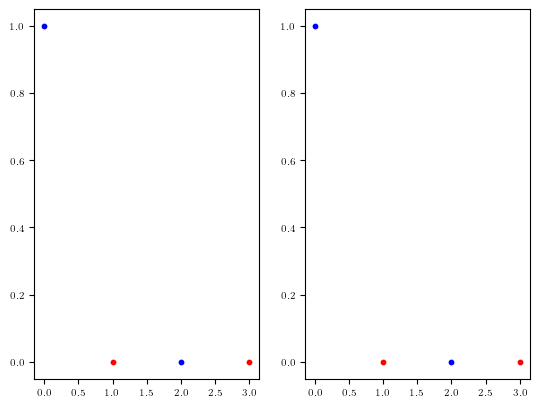

10.0%. Run time:   0.01s. Est. time left: 00:00:00:00
20.0%. Run time:   0.02s. Est. time left: 00:00:00:00
30.0%. Run time:   0.03s. Est. time left: 00:00:00:00
40.1%. Run time:   0.04s. Est. time left: 00:00:00:00
50.1%. Run time:   0.05s. Est. time left: 00:00:00:00
60.1%. Run time:   0.07s. Est. time left: 00:00:00:00
70.1%. Run time:   0.08s. Est. time left: 00:00:00:00
80.1%. Run time:   0.09s. Est. time left: 00:00:00:00
90.1%. Run time:   0.10s. Est. time left: 00:00:00:00
100.0%. Run time:   0.10s. Est. time left: 00:00:00:00
Total run time:   0.11s


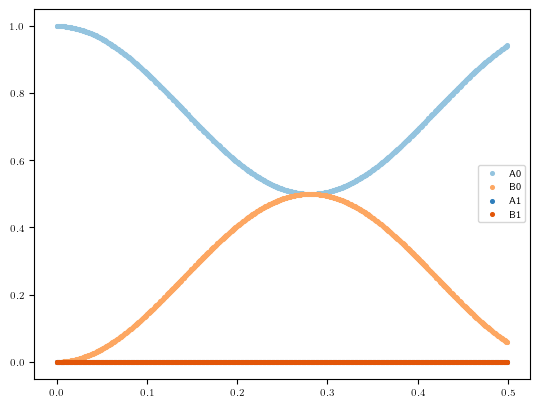

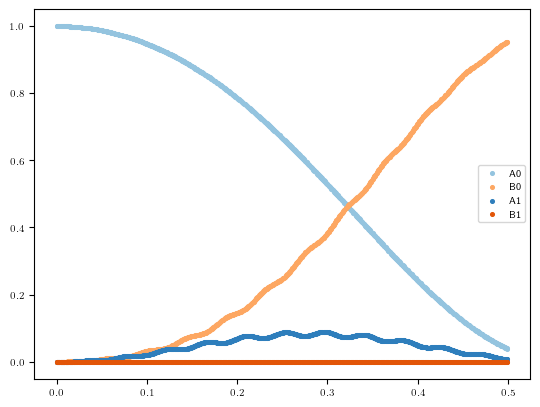

In [27]:

atol = 1e-16
a = 2

   

import matplotlib.cm as cm
orange = cm.Oranges
blue = cm.Blues

d = np.array([0,1])


# tsteps = 100
# dt = 0.2

tsteps = 800
dt = 0.5/tsteps
t = np.arange(tsteps)*dt
freq = 1/t[-1]
ph_scale = 1/10
def thermal_phonon_generator(excitations,chain_length):
    state = np.zeros(chain_length,dtype=np.int16)
    states = []
    if np.sum(state)==excitations:
        return 0
    for i in range(1,int(binom(chain_length+excitations,excitations))):
        state = add_one(state,excitations)
        if np.sum(state)==excitations:
            states.append(state.copy())
    # discard = int(factorial(excitations+chain_length-1)//(factorial(excitations-1)*factorial(chain_length)))
    # return discard
    return states
boson_number = 3
Sys_full = full_dynamics(chain_length,boson_number=boson_number,a=a,d=d,ph_scale=ph_scale)
def Hamiltonian_spph_for_tevol(t):
    # b = a/2+(b0-a/2)*np.cos(2*np.pi*freq*t)
    # Delta = np.sin(2*np.pi*freq*t)
    h=0#.2
    b = a/2
    Delta=0
    return Sys_full.Hamiltonian_1Dph(Delta,b,h,a,0,d,ph_scale)


down = tensor([basis(2,1) for i in range(chain_length)])

state_sp = 0
eig0 = np.zeros(chain_length)
# # eig0[:2] = 1
eig0[0] = 1
for i in range(chain_length):
    state_sp += Sys_full.sigmas_p[i]* down* eig0[i]

phonon0 = tensor([basis(boson_number,0) for i in range(chain_length)])
# state_sp = Sys_full.sigmas_p[0]* down
therm_numb = boson_number-1
phonon_gen = thermal_phonon_generator(therm_numb,chain_length)
eig_ph = np.ones(len(phonon_gen))
state_ph = 0
shift = 1
# for ind, phonon_state in enumerate(phonon_gen):
#     state = phonon0
#     # print(phonon_state)
#     for i in range(len(phonon_state)):
#         state = Sys_full.annihilation_phonon[i].dag()**(phonon_state[i]*shift)*state
#     # print(state.full().T)
#     state_ph += state.unit()*eig_ph[ind]

state_ph = Sys_full.annihilation_phonon[0].dag()*phonon0

# for n in range(chain_length):
# n=0
# psi0q = 0
# state_sp = 0
# for i in range(chain_length):   
#     # for j in range(chain_length):
#         state_sp += sigmas_p[i]* down*eig0[i]
        # state_ph = (annihilation_phonon[j].dag())**3*phonon0
        # psi0q += tensor(state_sp,state_ph.unit())*eig0[i,j]#eigenvals0[n,1+chain_length*i+j]
    
psiq = tensor(state_sp.unit(),state_ph.unit())
# psiq = psi0q.unit()
# print(psi0q.norm(),b,h)   
psiq.shape, Sys_full.projectors_eval[0].shape
expect(Sys_full.projectors_eval[0],psiq)
# psiq = tensor(psi0q,eig_generator_ph*phonon0)
# #
fig, ax = plt.subplots(1,2)
ax[0].scatter(Sys_full.latticeA[0,:],[expect(Sys_full.projectors_eval[2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[0].scatter(Sys_full.latticeB[0,:],[expect(Sys_full.projectors_eval[2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)

ax[1].scatter(Sys_full.latticeA[0,:],[expect(Sys_full.projectors_eval[chain_length+2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[1].scatter(Sys_full.latticeB[0,:],[expect(Sys_full.projectors_eval[chain_length+2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)
plt.show()
b= 1.3
# traj1 = sesolve(Hamiltonian_spph_for_tevol(0),psiq,t,e_ops=Sys_full.projectors_eval,options={"progress_bar":True,"store_final_state":True,"atol":atol,"rtol":atol})
traj1 = sesolve(Sys_full.Hamiltonian_1Dph(0,b,0),psiq,t,e_ops=Sys_full.projectors_eval,options={"progress_bar":True,"store_final_state":True,"atol":atol,"rtol":atol})
# t = t[:20],"store_states":TrueSys_full.a/2,
# print(Hamiltonian_spph_for_tevol(0).full().shape)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
for i in range(chain_length//2):
    ax2.scatter(t,traj1.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax2.scatter(t,traj1.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    ax.scatter(t,traj1.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax.scatter(t,traj1.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
# ax.scatter(t,traj1.expect[chain_length-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
# ax2.scatter(t,traj1.expect[chain_length*2-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
ax.legend()
ax2.legend()
plt.show()
    

In [28]:
def single_Hamiltonian(b,h,a,chain_length,interaction,Delta,d):
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*a
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*a + b * np.array([1,0])+h*np.array([0,1])
    dmat = np.zeros((chain_length,chain_length))
    ind = np.arange(chain_length,dtype=np.int16)
    inter_1 = interaction(latticeB[:,0]-latticeA[:,0],d)
    inter_2 = interaction(latticeB[:,0]-latticeA[:,1],d)
    dmat[ind[:-1:2],ind[1::2]]= inter_1
    dmat[ind[1::2],ind[:-1:2]]= inter_1
    dmat[ind[1:-2:2],ind[2:-1:2]] = inter_2
    dmat[ind[2:-1:2],ind[1:-2:2]] = inter_2
    dmat[ind[::2],ind[::2]] = Delta
    dmat[ind[1::2],ind[1::2]]= -Delta
    # print(inter_1,inter_2,b)
    return dmat

In [34]:
excit_phonons = 7
chain_length = 6
S= system(chain_length,excit_phonons,dip_dip,dip_derivative_full,a=a,full=False,ph_scale=1/6, d= d)
S.Hamiltonian(1.3,0,Delta=0).shape
Ham = S.Hamiltonian(1.3,0,Delta=0).full()
eigvals, eigvecs = np.linalg.eigh(Ham)

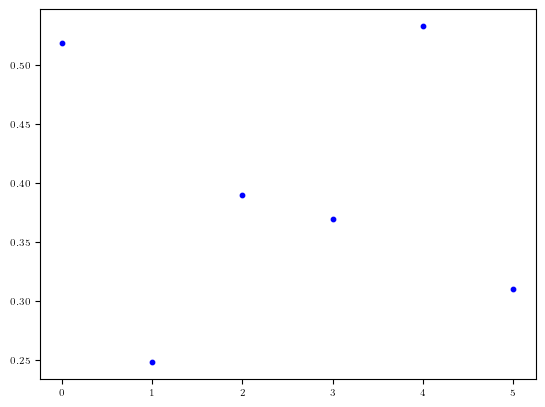

10.0%. Run time:   1.08s. Est. time left: 00:00:00:09
20.1%. Run time:   2.18s. Est. time left: 00:00:00:08
30.1%. Run time:   3.29s. Est. time left: 00:00:00:07
40.1%. Run time:   4.40s. Est. time left: 00:00:00:06
50.2%. Run time:   5.51s. Est. time left: 00:00:00:05
60.2%. Run time:   6.63s. Est. time left: 00:00:00:04
70.2%. Run time:   7.75s. Est. time left: 00:00:00:03
80.3%. Run time:   8.88s. Est. time left: 00:00:00:02
90.3%. Run time:  10.01s. Est. time left: 00:00:00:01
100.0%. Run time:  11.10s. Est. time left: 00:00:00:00
Total run time:  11.10s


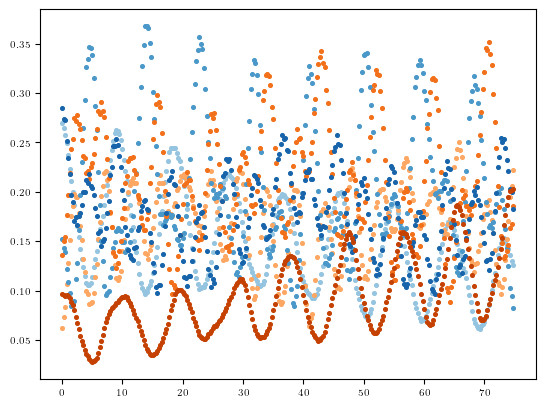

In [70]:
# boson_number -=1
increase = 0
exc_numbers = [8]
trajs = []
for l in exc_numbers:
# for l in range(boson_number-1,8):
    excit_phonons = l
    excit_spin = 1
    chain_length = 6
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    atol = 1e-16
    b=a/2
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*a
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*a + b*np.array([1,0])+h*np.array([0,1])
    dims_phonon = [excit_phonons+1]*chain_length
    dims_spin = [excit_spin+1]*chain_length

    ind = project_indices(excit_phonons,chain_length)  
    ind_spin = project_indices(excit_spin,chain_length)

    state_sp =0
    a = 3
    b0 = 1.8#2.
    # d = np.array([np.sqrt(1/3),np.sqrt(2/3)])
    d = np.array([0,1])
    dmat = single_Hamiltonian(b0,0,a,chain_length,dip_dip,0,d)
    eigvals, eigvecs = np.linalg.eigh(dmat)
    eigen = sort_eigenvalues(eigvals,eigvecs)
    # eig0 = 1/np.sqrt(2)*(eigen[1,1:]-eigen[0,1:])
    # eig0 = np.zeros(chain_length)
    # eig0[0] = 1
    fig, ax = plt.subplots(1,1)
    ax.scatter(np.arange(chain_length),eig0,color='blue',s=10)
    plt.show()
    # solo
    for i in range(chain_length):
        state_sp += project_vec(ind_spin,enr_fock([2]*chain_length,1,[1 if n==i else 0 for n in range(chain_length)]))* eig0[i]

    # vecph = np.zeros(int(factorial(chain_length+excit_phonons-1)/(factorial(excit_phonons)*factorial(chain_length-1)))) 
    # vecph[2] = 1

    # state_ph = Qobj(csr_matrix(vecph)).dag()
    # state_ph = project_vec(ind,enr_fock(chain_length*[excit_phonons+1],excit_phonons,[excit_phonons if j==1 else 0 for j in range(chain_length)]))
    # state_ph = Qobj(csr_matrix(eig_ph)).dag()
    # state_ph = 0
    # shift = 1
    # for indos, phonon_state in enumerate(phonon_gen):
        
    #     print(phonon_state)
        
            
    #     state_ph += project_vec(ind,enr_fock(chain_length*[excit_phonons+1],excit_phonons,phonon_state+increase*np.where(phonon_state>0,1,0))).unit() *eig_ph[indos]
            
    # print(state.full().T)
    
    state_ph = Qobj(csr_matrix(np.ones(int(factorial(chain_length+excit_phonons-1)/(factorial(excit_phonons)*factorial(chain_length-1)))))).dag()
    state0 = tensor(state_sp.unit(),state_ph.unit())

    psiq = state0.unit()

    S= system(chain_length,excit_phonons,dip_dip,dip_derivative_full,a=a,full=False,ph_scale=1/3, d= d)
    # S2= system(chain_length,excit_phonons,dip_dip,dip_derivative_full,a=a,full=False,ph_scale=1/12,sp_scale=0, d= d)
    
    # psiq = S.Hamiltonian(a/2,0) @ state0.unit()#.dag()
    tsteps = 300
    dt = 75/tsteps
    # tsteps = (200+100*excit_phonons)*4
    # # tsteps = 500
    # dt = 500/tsteps
    # print("thermal_phonons/traj_chain_length4_excite{:d}_time{:.2f}".format(excit_phonons,0.23))
    # return
    t = np.arange(tsteps)*dt
    freq = 1/t[-1]
    S.projectors_eval[0], psiq
    def time_traj(t):
        b = a/2+(b0-a/2)*np.cos(2*np.pi*freq*t)
        Delta = np.sin(2*np.pi*freq*t)*0.3
        return b, h, Delta
    S.param_trajectory = time_traj
    # fig, ax = plt.subplots(1,2)

    # ax[0].scatter(latticeA[0,:],[expect(S.projectors_eval[2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
    # ax[0].scatter(latticeB[0,:],[expect(S.projectors_eval[2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)

    # ax[1].scatter(latticeA[0,:],[expect(S.projectors_eval[chain_length+2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
    # ax[1].scatter(latticeB[0,:],[expect(S.projectors_eval[chain_length+2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)
    # plt.show()

    # psiq = S.Hamiltonian(a/2,0) @ state0.unit()#.dag()
    # fig, ax = plt.subplots(1,2)

    # ax[0].scatter(latticeA[0,:],[expect(S.projectors_eval[2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
    # ax[0].scatter(latticeB[0,:],[expect(S.projectors_eval[2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)

    # ax[1].scatter(latticeA[0,:],[expect(S.projectors_eval[chain_length+2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
    # ax[1].scatter(latticeB[0,:],[expect(S.projectors_eval[chain_length+2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)
    # plt.show()
    # break
    psiq = state0.unit()#.dag()
    # traj = sesolve(S.Hamiltonian_time,psiq,t,e_ops=S.projectors_eval,options={"progress_bar":True,"store_final_state":True,"atol":atol,"rtol":atol})
    # traj = sesolve(S.Hamiltonian_spin_time,state_sp,t,e_ops=S.project_spin,options={"progress_bar":True,"store_final_state":True,"atol":atol,"rtol":atol})
    traj = sesolve(S.Hamiltonian(b0,0),psiq,t,e_ops=S.projectors_eval,options={"store_final_state":True,"atol":atol,"rtol":atol,"store_states":True,"progress_bar":True}) 
    # traj = sesolve(S.Hamiltonian_spinner(b0,0,),state_sp,t,e_ops=S.project_spin,options={"store_final_state":True,"atol":atol,"rtol":atol,"store_states":True,"progress_bar":True}) 
    # traj2 = sesolve(S2.Hamiltonian(a/2,0),psiq,t,e_ops=S.projectors_eval,options={"store_final_state":True,"atol":atol,"rtol":atol,"store_states":True})
    # t = t[:20],"store_states":True
    # print("size Hamiltonian: ",S.Hamiltonian(b,h).full().shape)
    trajs.append(traj)
    # state_number = int(factorial(chain_length+excit_phonons-1)/(factorial(excit_phonons)*factorial(chain_length-1)))
    # traj_states = np.zeros((int(tsteps),state_number))
    # for j in range(int(tsteps)):
    #     for i in range(state_number):
    #         traj_states[j,i] = np.sqrt(np.sum(np.abs(traj.states[j].full()[i::state_number,0])**2))
    # marker = ["|","x","_"]
    # phonon_states = thermal_phonon_generator(2,chain_length)
    # for i in range(state_number):
    #         ax2.scatter(t,traj_states[:,i],s=10,label=phonon_states[i],marker=marker[i%3])
            # ax2.scatter(t,traj.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    fig, ax = plt.subplots(1,1)

    # means = []
    # bin = 50
    # for i in range(chain_length):
    #     steps = len(t)//bin
    #     mean_time = []
    #     means.append([])
    #     for j in range(steps):
    #         means[-1].append(np.mean(traj.expect[i][j*bin:(j+1)*bin]))
    #         mean_time.append(np.mean(t[j*bin:(j+1)*bin]))

    # fig2, ax2 = plt.subplots(1,1)
    for i in range(chain_length//2):
        # ax2.scatter(t,traj.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
        # ax2.scatter(t,traj.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
        # ax.scatter(mean_time,means[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
        # ax.scatter(mean_time,means[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")#
        ax.scatter(t,traj.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
        ax.scatter(t,traj.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")#
        # traj_comp_even = 0#trajs[0].expect[2*i]
        # traj_comp_odd = 0#trajs[0].expect[2*i+1]
        # ax2.scatter(t,traj_comp_even+traj2.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
        # ax2.scatter(t,traj_comp_odd+traj2.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
        # ax2.scatter(t,traj.expect[chain_length+2*i]-traj1.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
        # ax2.scatter(t,traj.expect[chain_length+2*i+1]-traj1.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
        # ax.scatter(t,traj.expect[2*i]-traj1.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
        # ax.scatter(t,traj.expect[2*i+1]-traj1.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    # ax.scatter(t,traj1.expect[chain_length-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
    # ax2.scatter(t,traj1.expect[chain_length*2-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
    # ax.legend()
    # ax2.legend()
    # plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"chain4_ricemele_1spto10oupling_doubletime_10phonons_Delta10.pdf")
    plt.show()
    # break
        

TypeError: 'Axes' object is not subscriptable

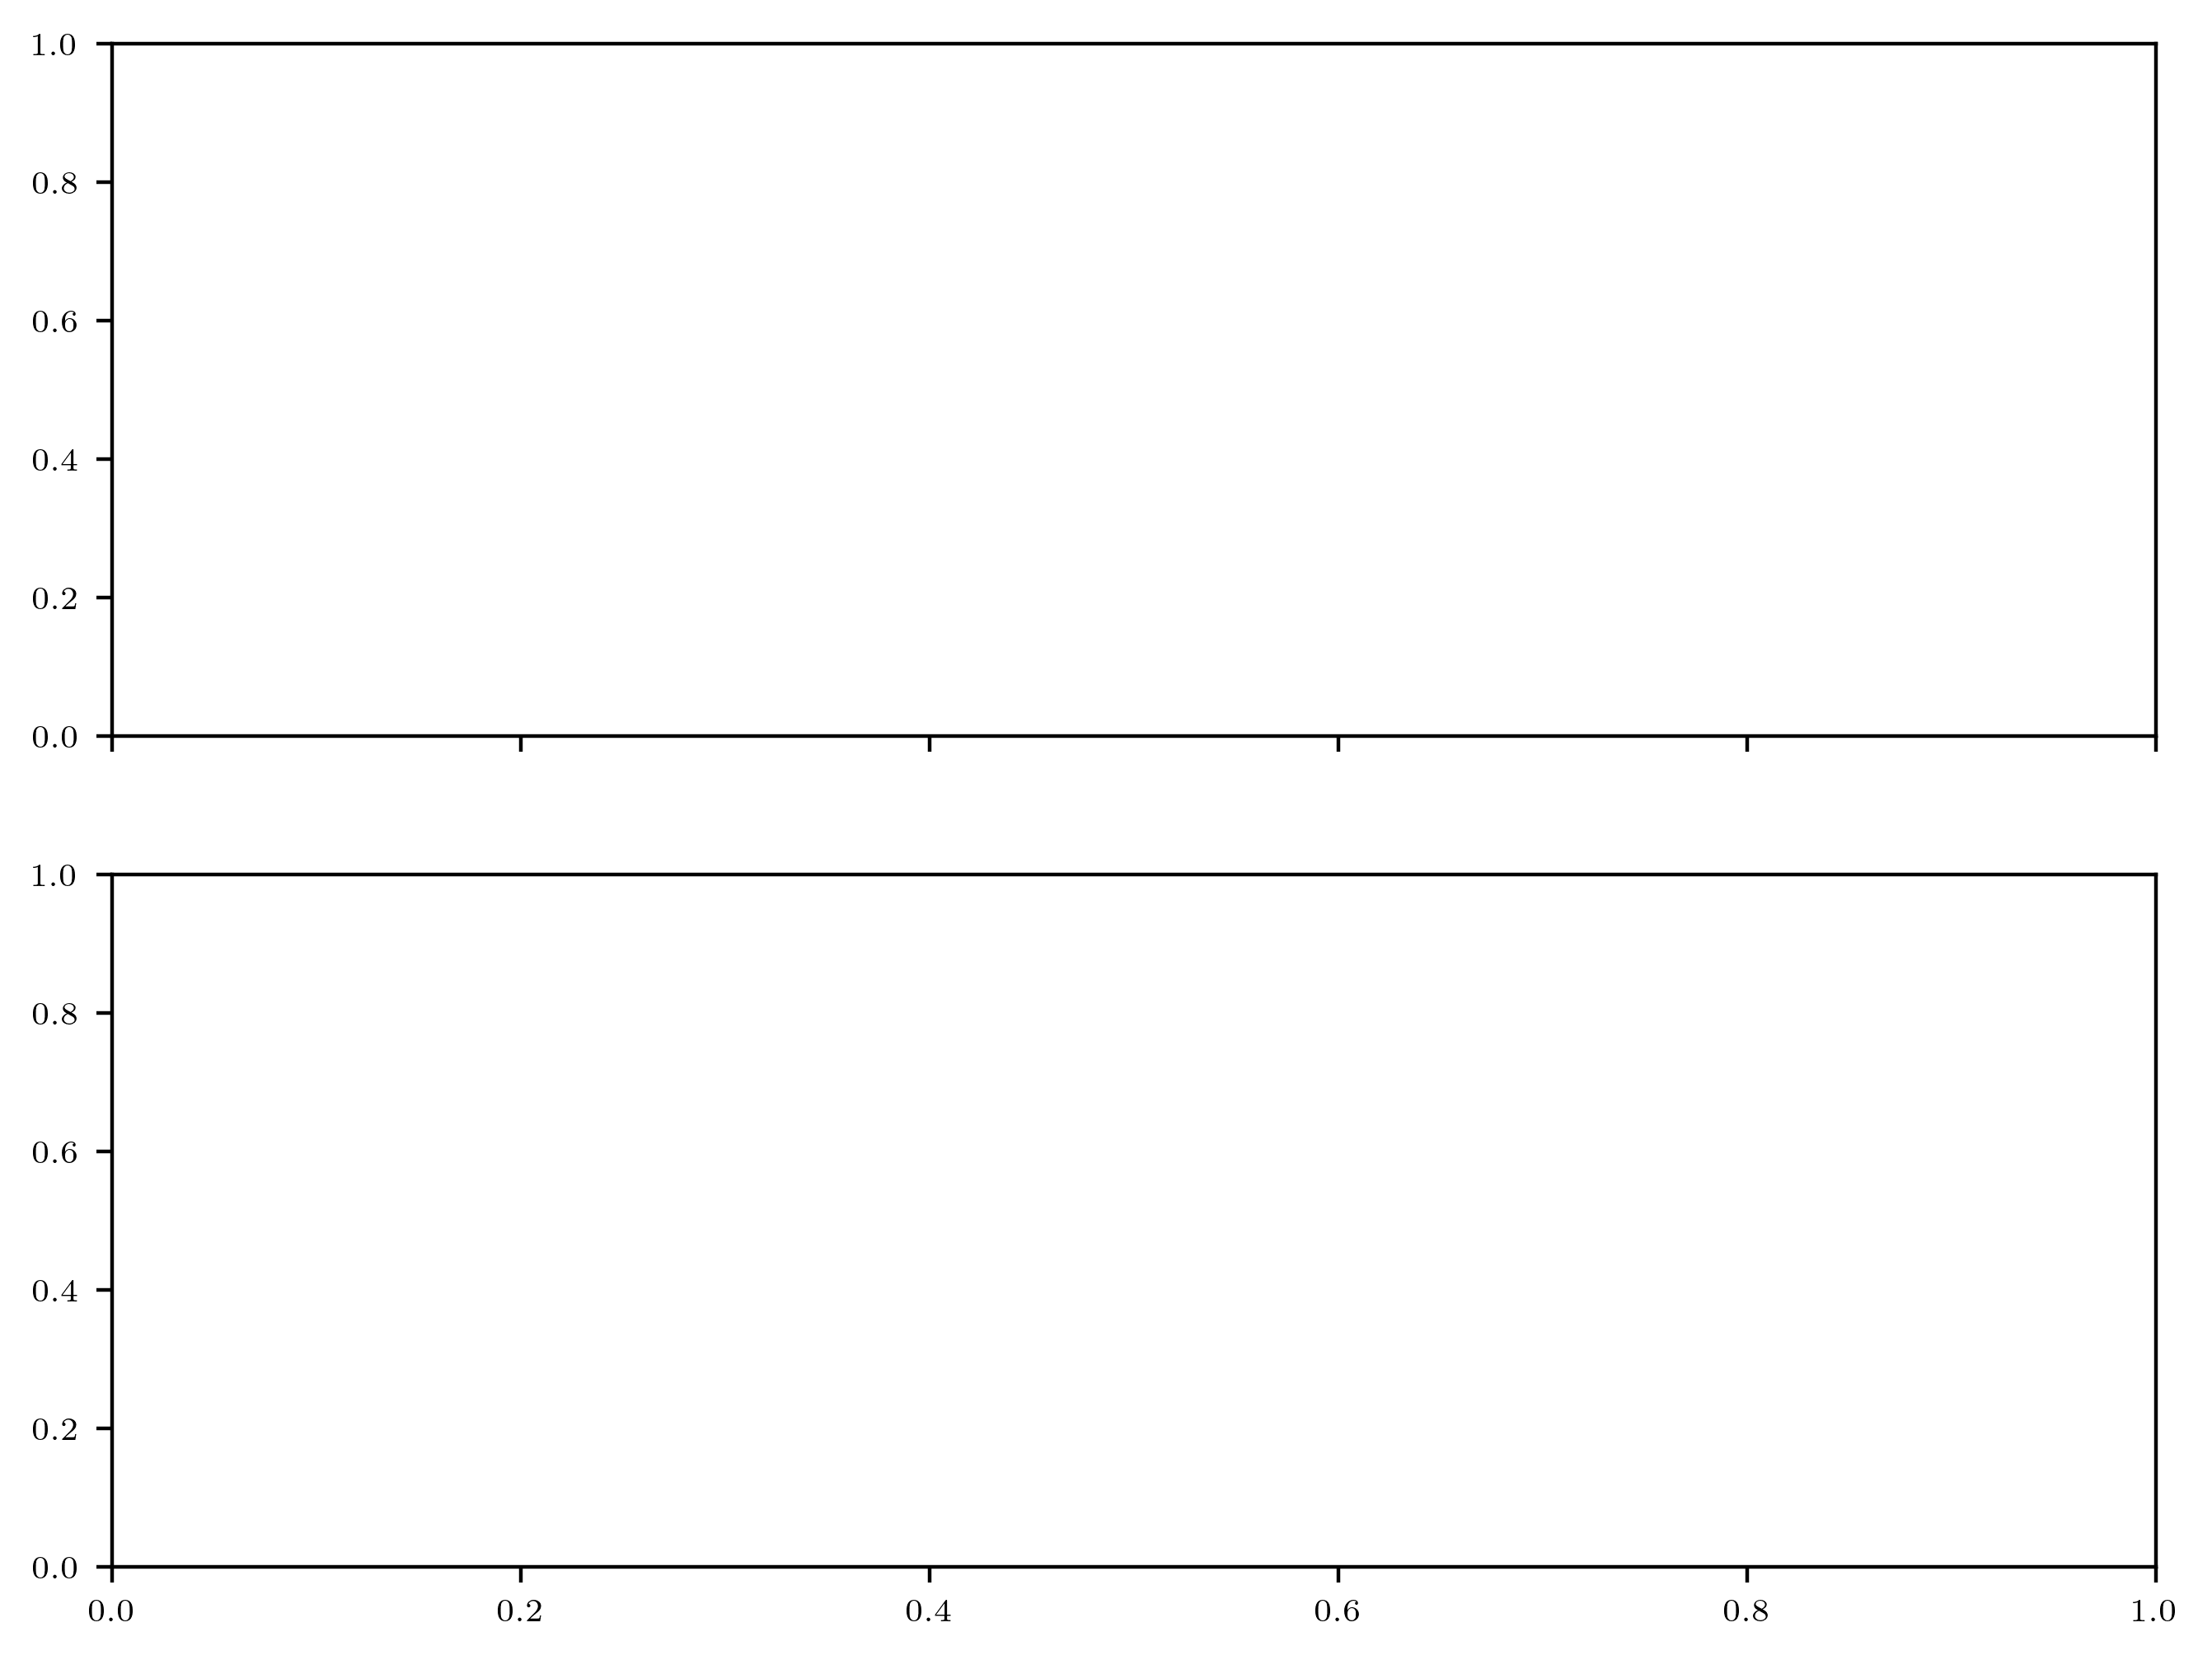

In [ ]:
# fig2, ax2 = plt.subplots(1,4)
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=8,fig_height=6,xax_share=True,joined=True)
from copy import deepcopy
pos = np.arange(3)
# fig, ax = plt.subplots(2,4,figsize=(8,8))
wrapper = [[],[]]
fig, ax = setup.return_fig((2,3))
for i, traj in enumerate(trajs):
    ax2 = ax[0]
    ax1 = ax[1]
    # tsteps = 200+100*exc_numbers[i]
    
    # dt = 400/tsteps
    
    # t = np.arange(tsteps)*dt
    ax2[i].set_title("excited phonons: {:d}".format(exc_numbers[i]))
    for j in range(chain_length//2):
        ax1[i].scatter(t,traj.expect[chain_length+2*j],color=blue(0.4+0.6*j/(chain_length//2+chain_length%2)),s=7,label=f'A{j}')
        ax1[i].scatter(t,traj.expect[chain_length+2*j+1],color=orange(0.4+0.6*j/(chain_length//2)),s=7,label=f"B{j}")
        ax2[i].scatter(t,traj.expect[2*j],color=blue(0.4+0.6*j/(chain_length//2+chain_length%2)),s=7,label=f'A{j}')
        ax2[i].scatter(t,traj.expect[2*j+1],color=orange(0.4+0.6*j/(chain_length//2)),s=7,label=f"B{j}")
        wrapper[0].append(lambda k=i: setup.format_ax(ax1[k],(2,3),j=0,set_ticks=False))
        wrapper[1].append(lambda k=i: setup.format_ax(ax2[k],(2,3),j=0,bottom=False,set_ticks=False))
        ax1[i] = wrapper[0][-1]()
        ax2[i] = wrapper[1][-1]()
        
    ax2[i].legend()
ax[0][0].set_ylabel("spin excitation")
ax[1][0].set_ylabel("phonon excitation")
ax[1][1].set_xlabel("time")
plt.subplots_adjust(hspace=0.1,wspace=0.24)
# plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"chain4_ricemele_1spto10oupling.pdf")
plt.show()

In [ ]:
project_vec(ind,enr_fock(chain_length*[excit_phonons+1],excit_phonons,phonon_state))
project_indices(excit_phonons,chain_length)
phonon_state
# enr_fock(chain_length*[excit_phonons+1],excit_phonons,phonon_state)

2 [0 0 0 2]
4 [0 0 1 1]
5 [0 0 2 0]
7 [0 1 0 1]
8 [0 1 1 0]
9 [0 2 0 0]
11 [1 0 0 1]
12 [1 0 1 0]
13 [1 1 0 0]
14 [2 0 0 0]


array([0, 0, 0, 1], dtype=int16)

In [ ]:
import numpy as np


def build_hamiltonian(N, V_list, n_motional):
    """
    Build the Hamiltonian for a 1D chain with spin and motional degrees of freedom.

    H = sum_j  H_ph^{j,j+1} * a_j^dag * a_{j+1} + h.c.

    where H_ph^{j,j+1} = V_j * (p_j^dag p_{j+1} + p_{j+1}^dag p_j
                                 - p_j^dag p_j   - p_{j+1}^dag p_{j+1})

    Parameters
    ----------
    N           : int   — number of sites
    V_list      : list  — hopping amplitudes V_j, length N-1
    n_motional  : int   — Fock-space truncation for each motional mode

    Returns
    -------
    H           : Qobj  — total Hamiltonian
    projectors  : list  — [n_spin_0, ..., n_spin_{N-1},
                            n_mot_0,  ..., n_mot_{N-1}]
                          Each n_spin_j is the spin occupation number operator
                          a_j^dag a_j embedded in the full Hilbert space.
                          Each n_mot_j is the motional occupation number operator
                          p_j^dag p_j embedded in the full Hilbert space.
    """

    # ------------------------------------------------------------------ #
    # Local operators                                                      #
    # ------------------------------------------------------------------ #

    a_spin = destroy(2)
    p_mot  = destroy(n_motional)

    n_spin_local = a_spin.dag() @ a_spin   # a^dag a  (spin)
    n_mot_local  = p_mot.dag()  @ p_mot    # p^dag p  (motional)

    id_spin = qeye(2)
    id_mot  = qeye(n_motional)

    # ------------------------------------------------------------------ #
    # Helper: embed a single-site operator in the full N-site Hilbert space
    # ------------------------------------------------------------------ #

    def embed(op_spin, op_mot, site):
        ops = []
        for s in range(N):
            if s == site:
                ops.append(tensor(op_spin, op_mot))
            else:
                ops.append(tensor(id_spin, id_mot))
        return tensor(ops)

    def A(j):    return embed(a_spin,        id_mot,      j)
    def Adag(j): return embed(a_spin.dag(),  id_mot,      j)
    def P(j):    return embed(id_spin,       p_mot,       j)
    def Pdag(j): return embed(id_spin,       p_mot.dag(), j)
    def Nj(j):   return embed(id_spin,       n_mot_local, j)

    # ------------------------------------------------------------------ #
    # Build H                                                              #
    # ------------------------------------------------------------------ #

    H = tensor([qeye([2, n_motional])] * N) * 0

    for j in range(N - 1):
        V = V_list[j]

        H_ph = V * (Pdag(j) @ P(j+1)
                  + Pdag(j+1) @ P(j)
                  - Nj(j)
                  - Nj(j+1))

        spin_hop = Adag(j) @ A(j+1)

        term = H_ph @ spin_hop
        H += term + term.dag()

    # ------------------------------------------------------------------ #
    # Occupation number operators                                          #
    #                                                                      #
    # n_spin_j = a_j^dag a_j  (spin occupation, 0 or 1)                   #
    # n_mot_j  = p_j^dag p_j  (motional occupation, 0 to n_motional-1)    #
    # ------------------------------------------------------------------ #

    spin_number_ops = [embed(n_spin_local, id_mot, j) for j in range(N)]
    mot_number_ops  = [embed(id_spin, n_mot_local,  j) for j in range(N)]
    spin_destr_ops = [embed(a_spin, id_mot, j) for j in range(N)]
    mot_destr_ops  = [embed(id_spin, p_mot,  j) for j in range(N)]

    number_ops = spin_number_ops + mot_number_ops

    return H, number_ops, spin_destr_ops, mot_destr_ops




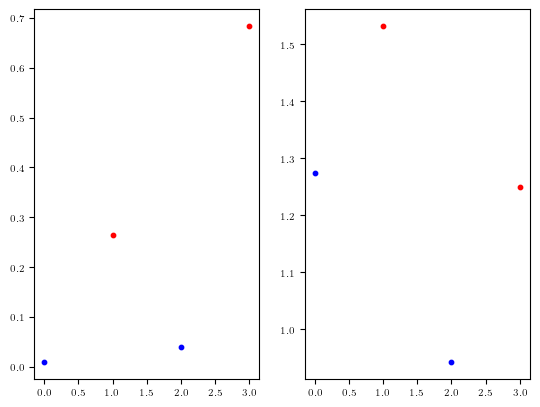

10.0%. Run time:   0.22s. Est. time left: 00:00:00:01
20.0%. Run time:   0.42s. Est. time left: 00:00:00:01
30.0%. Run time:   0.62s. Est. time left: 00:00:00:01
40.1%. Run time:   0.83s. Est. time left: 00:00:00:01
50.1%. Run time:   1.03s. Est. time left: 00:00:00:01
60.1%. Run time:   1.23s. Est. time left: 00:00:00:00
70.1%. Run time:   1.43s. Est. time left: 00:00:00:00
80.1%. Run time:   1.63s. Est. time left: 00:00:00:00
90.1%. Run time:   1.83s. Est. time left: 00:00:00:00
100.0%. Run time:   2.05s. Est. time left: 00:00:00:00
Total run time:   2.05s


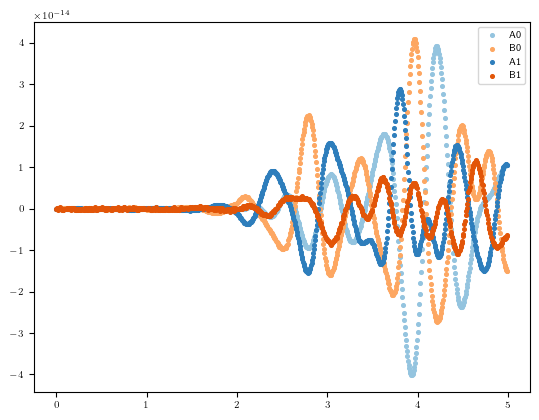

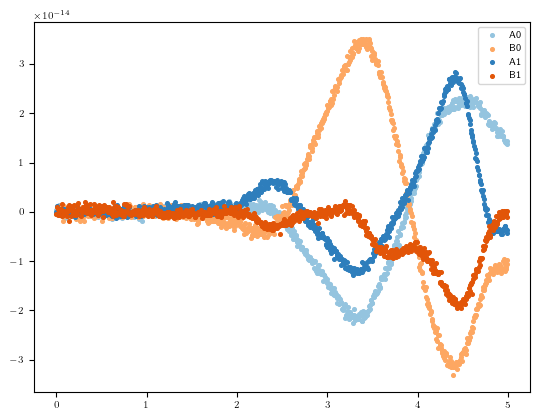

In [ ]:

atol = 1e-16
a = 2

   

import matplotlib.cm as cm
orange = cm.Oranges
blue = cm.Blues

d = np.array([0,1])

latticeA = np.zeros((2,chain_length//2+chain_length%2))
latticeB = np.zeros((2,chain_length//2))
for n in range(latticeA.shape[1]):
    latticeA[:,n] = n*np.array([1,0])*a
for n in range(latticeB.shape[1]):
    latticeB[:,n] = n*np.array([1,0])*a + a/2*np.array([1,0])
# tsteps = 100
# dt = 0.2


freq = 1/t[-1]
ph_scale = 1/50
def thermal_phonon_generator(excitations,chain_length):
    state = np.zeros(chain_length,dtype=np.int16)
    states = []
    if np.sum(state)==excitations:
        return 0
    for i in range(1,int(binom(chain_length+excitations,excitations))):
        state = add_one(state,excitations)
        if np.sum(state)==excitations:
            states.append(state.copy())
    # discard = int(factorial(excitations+chain_length-1)//(factorial(excitations-1)*factorial(chain_length)))
    # return discard
    return states
boson_number = 6

Ham, projectors_eval, spin_destr, ph_destr = build_hamiltonian(chain_length, [1]*(chain_length-1), boson_number)

down = tensor([basis(2,0) for i in range(chain_length)])
vac_site     = tensor(basis(2, 0), basis(boson_number, 0))  # |0_sp, 0_mot>
vac = tensor([vac_site] * chain_length)

# eig0 = np.zeros(chain_length)
# # eig0[:2] = 1
# eig0[-1] = 1



# state_sp = Sys_full.sigmas_p[0]* down
phonon_gen = thermal_phonon_generator(boson_number-1,chain_length)
state0 = 0
for ind, phonon_state in enumerate(phonon_gen):
    state = vac
    # print(phonon_state)
    for i in range(len(phonon_state)):
        state = ph_destr[i].dag()**phonon_state[i]*state
    # print(state.full().T)
    state0 += state.unit()*eig_ph[ind]

psiq = 0
for i in range(chain_length):
    psiq += spin_destr[i].dag()* state0* eig0[i]
# state_ph = Sys_full.annihilation_phonon[2].dag()**3*phonon0

# for n in range(chain_length):
# n=0
# psi0q = 0
# state_sp = 0
# for i in range(chain_length):   
#     # for j in range(chain_length):
#         state_sp += sigmas_p[i]* down*eig0[i]
        # state_ph = (annihilation_phonon[j].dag())**3*phonon0
        # psi0q += tensor(state_sp,state_ph.unit())*eig0[i,j]#eigenvals0[n,1+chain_length*i+j]
    

psiq = psiq.unit()
# print(psi0q.norm(),b,h)   
psiq.shape, Sys_full.projectors_eval[0].shape
# expect(Sys_full.projectors_eval[0],psiq)
# psiq = tensor(psi0q,eig_generator_ph*phonon0)
# #
fig, ax = plt.subplots(1,2)
ax[0].scatter(latticeA[0,:],[expect(projectors_eval[2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[0].scatter(latticeB[0,:],[expect(projectors_eval[2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)

ax[1].scatter(latticeA[0,:],[expect(projectors_eval[chain_length+2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[1].scatter(latticeB[0,:],[expect(projectors_eval[chain_length+2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)
plt.show()
# traj1 = sesolve(Hamiltonian_spph_for_tevol(0),psiq,t,e_ops=Sys_full.projectors_eval,options={"progress_bar":True,"store_final_state":True,"atol":atol,"rtol":atol})
traj = sesolve(Ham,psiq,t,e_ops=projectors_eval,options={"progress_bar":True,"store_final_state":True,"atol":atol,"rtol":atol})
# t = t[:20],"store_states":True
# print(Hamiltonian_spph_for_tevol(0).full().shape)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
for i in range(chain_length//2):
    # ax2.scatter(t,traj1.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    # ax2.scatter(t,traj1.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    # ax.scatter(t,traj1.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    # ax.scatter(t,traj1.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    ax2.scatter(t,traj.expect[chain_length+2*i]-traj1.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax2.scatter(t,traj.expect[chain_length+2*i+1]-traj1.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    ax.scatter(t,traj.expect[2*i]-traj1.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax.scatter(t,traj.expect[2*i+1]-traj1.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    
# ax.scatter(t,traj1.expect[chain_length-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
# ax2.scatter(t,traj1.expect[chain_length*2-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
ax.legend()
ax2.legend()
plt.show()
    

In [ ]:
project_vec([1,3],enr_fock([3]*chain_length,2,[1 if n==0 else 0 for n in range(chain_length)]))

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]]

In [ ]:
enr_fock([2]*chain_length,1,[1 if n==0 else 0 for n in range(chain_length)])
# projectors_eval[0]
sigmas_p[0]*down
excit_phonons = 2*chain_length
excit_spin = 1

dims_phonon = [excit_phonons+1]*chain_length
dims_spin = [excit_spin+1]*chain_length
rho = enr_thermal_dm(dims_phonon,excit_phonons,0.5)
dest = enr_destroy(dims_phonon,excit_phonons)
state = enr_fock([2]*chain_length,1,[1 if n==0 else 0 for n in range(chain_length)])
rho_spin = state * state.dag()
ident_spin = enr_identity(dims_spin,excit_spin)
project = tensor(ident_spin,dest[0])
rho = tensor(rho_spin,rho)
S= system(chain_length,excit_phonons,dip_dip,dip_derivative_full,a=2)
# S.project_phonon[0].shape, rho.shape
# S.projecto[0].shape, dest[0].shape
(S.Hamiltonian(0.8,0.2)*rho).tr()

35.62418124587302 -2.984970901966542 0.02 phonon


0j

In [ ]:
excit_phonons = 1
excit_spin = 1

dims_phonon = [excit_phonons+1]*chain_length
dims_spin = [excit_spin+1]*chain_length

ind = project_indices(excit_phonons,chain_length)  

state0 = 0
state_sp =0
for i in range(chain_length):
    for j in range(chain_length):
        state_sp = enr_fock([2]*chain_length,1,[1 if n==i else 0 for n in range(chain_length)])
        # state_sp = Qobj(csr_matrix([1 if n==i else 0 for n in range(chain_length)])).dag()# * eig0[i,j]
        state_ph = enr_fock([excit_phonons+1]*chain_length,excit_phonons,[excit_phonons if n==j else 0 for n in range(chain_length)])
        # print("qutip: ",enr_fock([3]*chain_length,2,[2 if n==j else 0 for n in range(chain_length)]))
        # state_ph = Qobj(csr_matrix([2 if n==j else 0 for n in range(chain_length)]))
        # print(state_ph)
        state0 += tensor(state_sp,state_ph) * eig0[i,j]
        # break




# state_ph = Qobj(csr_matrix(np.ones(int(factorial(chain_length+excit_phonons-1)/(factorial(excit_phonons)*factorial(chain_length-1))))))
# state0 = tensor(state_sp,state_ph)
rho1 = state0 * state0.dag()
psiq = state0.unit()#.dag()
print(psiq.norm(),b,h)   
S= system(chain_length,excit_phonons,dip_dip,dip_derivative_full,a=2,full=True)
projectors_eval2 = S.project_spin + S.project_phonon
# psiq = tensor(psi0q,eig_generator_ph*phonon0)
#
S.projectors_eval[0], psiq

fig, ax = plt.subplots(1,2)
ax[0].scatter(latticeA[0,:],[expect(S.projectors_eval[2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[0].scatter(latticeB[0,:],[expect(S.projectors_eval[2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)

ax[1].scatter(latticeA[0,:],[expect(S.projectors_eval[chain_length+2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[1].scatter(latticeB[0,:],[expect(S.projectors_eval[chain_length+2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)
plt.show()
traj = sesolve(S.Hamiltonian(b,h),psiq,t,e_ops=S.projectors_eval,options={"progress_bar":True,"store_final_state":True,"atol":atol,"rtol":atol})
# t = t[:20],"store_states":True
print("size Hamiltonian: ",S.Hamiltonian(b,h).full().shape)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
for i in range(chain_length//2):
    ax2.scatter(t,traj.expect[chain_length+2*i]-traj1.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax2.scatter(t,traj.expect[chain_length+2*i+1]-traj1.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    ax.scatter(t,traj.expect[2*i]-traj1.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax.scatter(t,traj.expect[2*i+1]-traj1.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
# ax.scatter(t,traj.expect[chain_length-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
# ax2.scatter(t,traj.expect[chain_length*2-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
ax.legend()
ax2.legend()
plt.show()


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
chain_length = 3
ind = [0,1,2,3,4,8,12]
ind = [5,6,7,9,10,11,13,14,15]
def print_mat(mat):
    for i in range(mat.shape[0]):
        print("  ".join([f"{mat[i,j]:.2f}" for j in range(mat.shape[1])]))
S= system(chain_length,excit_phonons,dip_dip,dip_derivative_full,a=2,full=False)
S2= system(chain_length,excit_phonons,dip_dip,dip_derivative_full,a=2,full=True)
print_mat(np.round(np.real(S.Hamiltonian(b,h).full()),2)-np.round(np.real(S2.Hamiltonian(b,h).full()[ind,:][:,ind]),2))

0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00


In [ ]:
S.project_phonon[0]

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 1.]]

1.0000000000000002 1.0 0.07161583280860828


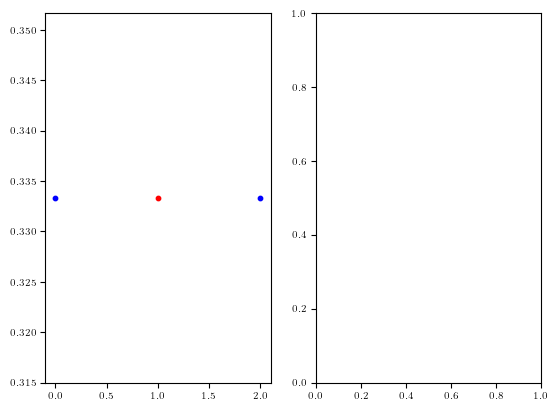

10.0%. Run time:   0.00s. Est. time left: 00:00:00:00
20.1%. Run time:   0.00s. Est. time left: 00:00:00:00
30.1%. Run time:   0.00s. Est. time left: 00:00:00:00
40.1%. Run time:   0.00s. Est. time left: 00:00:00:00
50.2%. Run time:   0.00s. Est. time left: 00:00:00:00
60.2%. Run time:   0.00s. Est. time left: 00:00:00:00
70.2%. Run time:   0.00s. Est. time left: 00:00:00:00
80.3%. Run time:   0.00s. Est. time left: 00:00:00:00
90.3%. Run time:   0.00s. Est. time left: 00:00:00:00
100.0%. Run time:   0.01s. Est. time left: 00:00:00:00
Total run time:   0.01s


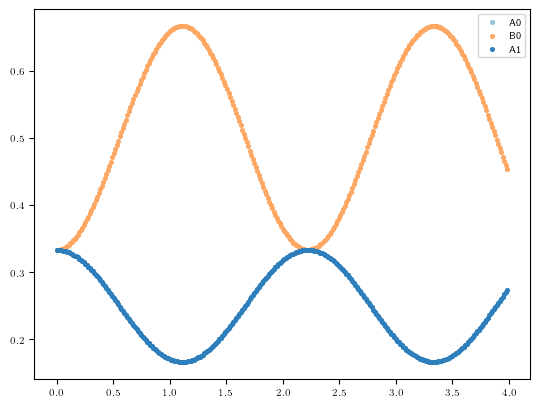

In [ ]:
excit_phonons = 0
excit_spin = 1
chain_length = 3
latticeA = np.zeros((2,chain_length//2+chain_length%2))
latticeB = np.zeros((2,chain_length//2))
atol = 1e-16
for n in range(latticeA.shape[1]):
    latticeA[:,n] = n*np.array([1,0])*a
for n in range(latticeB.shape[1]):
    latticeB[:,n] = n*np.array([1,0])*a + b*np.array([1,0])+h*np.array([0,1])
dims_phonon = [excit_phonons+1]*chain_length
dims_spin = [excit_spin+1]*chain_length

ind = project_indices(excit_phonons,chain_length)  
ind_spin = project_indices(excit_spin,chain_length)
state0 = 0
state_sp =0
b0 = 1.6
# d = np.array([np.sqrt(1/3),np.sqrt(2/3)])
dmat = photon_Hamiltonian(b0,h,a,chain_length,dip_dip,0,d)
eig, vec = np.linalg.eig(dmat)
eigen = sort_eigenvalues(eig,vec)
# eig0 = 1/2*(eigen[1,1:]+eigen[1,1:])
# eig0 = eigen[1,1:]
# np.sqrt(2)
eig0 = np.zeros(chain_length)
eig0[:] = 1
for i in range(chain_length):
    # for j in range(chain_length):
        state_sp += project_vec(ind_spin,enr_fock([2]*chain_length,1,[1 if n==i else 0 for n in range(chain_length)]))* eig0[i]
        # state_sp = Qobj(csr_matrix([1 if n==i else 0 for n in range(chain_length)])).dag()# 
        # state_ph = project_vec(ind,enr_fock([excit_phonons+1]*chain_length,excit_phonons,[excit_phonons if n==j else 0 for n in range(chain_length)]))
        # print("qutip: ",enr_fock([3]*chain_length,2,[2 if n==j else 0 for n in range(chain_length)]))
        # state_ph = Qobj(csr_matrix([2 if n==j else 0 for n in range(chain_length)]))
        # print(state_ph)
        # state0 += tensor(state_sp,state_ph) * eig0[i,j]
        # break



# stateph = np.zeros(int(factorial(chain_length+excit_phonons-1)/(factorial(excit_phonons)*factorial(chain_length-1))))
# stateph[3] = 1
# state_ph = Qobj(csr_matrix(stateph)).dag()
# # state_ph = Qobj(csr_matrix(np.ones(int(factorial(chain_length+excit_phonons-1)/(factorial(excit_phonons)*factorial(chain_length-1)))))).dag()
# state0 = tensor(state_sp,state_ph)
# rho1 = state0 * state0.dag()
psiq = state_sp.unit()
# psiq = state0.unit()#.dag()
print(psiq.norm(),b,h)   
S= system(chain_length,excit_phonons,dip_dip,dip_derivative_full,a=2,full=False,d=d)
# projectors_eval2 = S.project_spin + S.project_phonon
# psiq = tensor(psi0q,eig_generator_ph*phonon0)
#

tsteps = 300
dt = 4/tsteps
t = np.arange(tsteps)*dt
freq = 1/t[-1]
S.projectors_eval[0], psiq
def time_traj(t):
    return a/2, 0, 0
    b = a/2+(b0-a/2)*np.cos(2*np.pi*freq*t)
    Delta = np.sin(2*np.pi*freq*t)
    return b, h, Delta
S.param_trajectory = time_traj
fig, ax = plt.subplots(1,2)
ax[0].scatter(latticeA[0,:],[expect(S.projectors_eval[2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[0].scatter(latticeB[0,:],[expect(S.projectors_eval[2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)

# ax[1].scatter(latticeA[0,:],[expect(S.projectors_eval[chain_length+2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
# ax[1].scatter(latticeB[0,:],[expect(S.projectors_eval[chain_length+2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)
plt.show()
traj = sesolve(S.Hamiltonian_spin_time(0),psiq,t,e_ops=S.projectors_eval,options={"progress_bar":True,"store_final_state":True,"atol":atol,"rtol":atol})
# traj = sesolve(S.Hamiltonian(a/2,0),psiq,t,e_ops=S.projectors_eval,options={"progress_bar":True,"store_final_state":True,"atol":atol,"rtol":atol})
# t = t[:20],"store_states":True
# print("size Hamiltonian: ",S.Hamiltonian(b,h).full().shape)
fig, ax = plt.subplots(1,1)
# fig2, ax2 = plt.subplots(1,1)
for i in range(chain_length//2+chain_length%2):
    # ax2.scatter(t,traj.expect[chain_length+2*i]-traj1.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    # ax2.scatter(t,traj.expect[chain_length+2*i+1]-traj1.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    # ax.scatter(t,traj.expect[2*i]-traj1.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    # ax.scatter(t,traj.expect[2*i+1]-traj1.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    # ax2.scatter(t,traj.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    # ax2.scatter(t,traj.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    ax.scatter(t,traj.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    if 2*i+1 < chain_length:
        ax.scatter(t,traj.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
# ax.scatter(t,traj.expect[chain_length-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
# ax2.scatter(t,traj.expect[chain_length*2-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
ax.legend()
ax2.legend()
plt.show()


10.0%. Run time:   6.27s. Est. time left: 00:00:00:56
20.0%. Run time:   8.08s. Est. time left: 00:00:00:32
30.0%. Run time:   8.49s. Est. time left: 00:00:00:19
40.1%. Run time:  10.27s. Est. time left: 00:00:00:15
50.1%. Run time:  18.94s. Est. time left: 00:00:00:18
60.1%. Run time:  28.63s. Est. time left: 00:00:00:19
70.1%. Run time:  32.06s. Est. time left: 00:00:00:13
80.1%. Run time:  32.54s. Est. time left: 00:00:00:08
90.1%. Run time:  33.81s. Est. time left: 00:00:00:03
100.0%. Run time:  39.05s. Est. time left: 00:00:00:00
Total run time:  39.05s


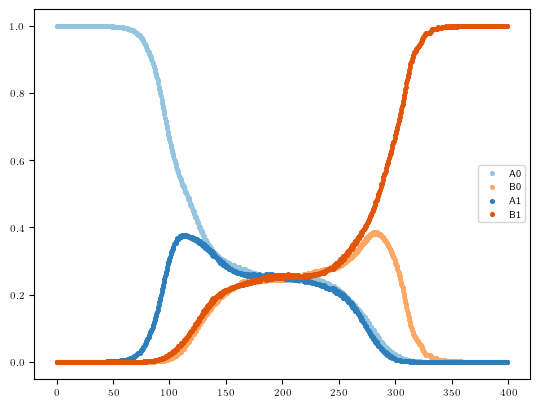

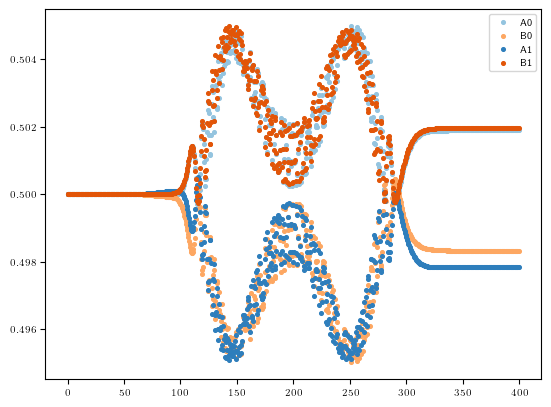

In [ ]:
excit_phonons = 2
chain_length = 4
ind = project_indices(excit_phonons,chain_length)  
ind_spin = project_indices(excit_spin,chain_length)

state_sp =0
b0 = 1.6
d = np.array([np.sqrt(1/3),np.sqrt(2/3)])
h = 0.2
eig0 = np.zeros(chain_length)
eig0[0] = 1
for i in range(chain_length):
    state_sp += project_vec(ind_spin,enr_fock([2]*chain_length,1,[1 if n==i else 0 for n in range(chain_length)]))* eig0[i]

state_ph = Qobj(csr_matrix(np.ones(int(factorial(chain_length+excit_phonons-1)/(factorial(excit_phonons)*factorial(chain_length-1)))))).dag()
state0 = tensor(state_sp,state_ph)

psiq = state0.unit()#.dag()

S= system(chain_length,excit_phonons,dip_dip,dip_derivative_full,a=2,full=False,ph_scale=1/50)
#
tsteps = 800#7/5*100*excit_phonons-40
dt = 400/tsteps
# print("thermal_phonons/traj_chain_length4_excite{:d}_time{:.2f}".format(excit_phonons,0.23))
# return
t = np.arange(tsteps)*dt
freq = 1/t[-1]
S.projectors_eval[0], psiq
def time_traj(t):
    b = a/2+(b0-a/2)*np.cos(2*np.pi*freq*t)
    Delta = np.sin(2*np.pi*freq*t)
    return b, h, Delta
S.param_trajectory = time_traj

traj = sesolve(S.Hamiltonian_time,psiq,t,e_ops=S.projectors_eval,options={"atol":atol,"rtol":atol,"progress_bar":True})
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
for i in range(chain_length//2):
    # ax2.scatter(t,traj.expect[chain_length+2*i]-traj1.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    # ax2.scatter(t,traj.expect[chain_length+2*i+1]-traj1.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    # ax.scatter(t,traj.expect[2*i]-traj1.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    # ax.scatter(t,traj.expect[2*i+1]-traj1.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    ax2.scatter(t,traj.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax2.scatter(t,traj.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    ax.scatter(t,traj.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax.scatter(t,traj.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
# ax.scatter(t,traj.expect[chain_length-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
# ax2.scatter(t,traj.expect[chain_length*2-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
ax.legend()
ax2.legend()
plt.show()

In [ ]:
from time import time
from qutip.fileio import qsave, qload
def wrapper(excit_phonons): 
    
    excit_spin = 1
    chain_length = 4
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    atol = 1e-16
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*a
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*a + b*np.array([1,0])+h*np.array([0,1])
    dims_phonon = [excit_phonons+1]*chain_length
    dims_spin = [excit_spin+1]*chain_length

    ind = project_indices(excit_phonons,chain_length)  
    ind_spin = project_indices(excit_spin,chain_length)

    state_sp =0
    b0 = 1.6
    d = np.array([np.sqrt(1/3),np.sqrt(2/3)])

    eig0 = np.zeros(chain_length)
    eig0[0] = 1
    for i in range(chain_length):
        state_sp += project_vec(ind_spin,enr_fock([2]*chain_length,1,[1 if n==i else 0 for n in range(chain_length)]))* eig0[i]

    state_ph = Qobj(csr_matrix(np.ones(int(factorial(chain_length+excit_phonons-1)/(factorial(excit_phonons)*factorial(chain_length-1)))))).dag()
    state0 = tensor(state_sp,state_ph)

    psiq = state0.unit()#.dag()
    
    S= system(chain_length,excit_phonons,dip_dip,dip_derivative_full,a=2,full=False,ph_scale=1/50)
    #
    tsteps = 7/5*100*excit_phonons+300
    dt = 400/tsteps
    # print("thermal_phonons/traj_chain_length4_excite{:d}_time{:.2f}".format(excit_phonons,0.23))
    # return
    t = np.arange(tsteps)*dt
    freq = 1/t[-1]
    S.projectors_eval[0], psiq
    def time_traj(t):
        b = a/2+(b0-a/2)*np.cos(2*np.pi*freq*t)
        Delta = np.sin(2*np.pi*freq*t)
        return b, h, Delta
    S.param_trajectory = time_traj
    t1 = time()
    traj = sesolve(S.Hamiltonian_time,psiq,t,e_ops=S.projectors_eval,options={"atol":atol,"rtol":atol,"store_final_state":True})
    t2 = time()
    qsave(traj.final_state,"thermal_phonons/chainlength4/final_state_excite{:d}".format(excit_phonons))
    np.save("thermal_phonons/chainlength4/traj_excite{:d}_time{:.2f}".format(excit_phonons,t2-t1),traj.expect)
    print("excitation_number: ",excit_phonons,"time: ",t2-t1)
    return

# po = Pool(3)
# res = po.imap(wrapper,np.arange(1,4),chunksize=1)
# for index, res in enumerate(res):
#     A = res
# wrapper(3)

In [ ]:
phonon_states = thermal_phonon_generator(2,3)

In [ ]:
12**2*(24-16*np.sqrt(2)), 3.14365991**2+2*2.22290324**2, 12/np.sqrt(10)*(1-np.sqrt(2))*2

(np.float64(197.65195229238878),
 19.7651952585462,
 np.float64(-3.1436599075948806))

In [ ]:
expect(S.project_phonon[0],S.Hamiltonian_phonon_only(a/2,0) @ state_ph.unit()),S.Hamiltonian_phonon_only(a/2,0) @ state_ph.unit()

(19.765195229238927,
 Quantum object: dims=[[10], [1]], shape=(10, 1), type='ket', dtype=CSR
 Qobj data =
 [[ 0.        ]
  [ 0.        ]
  [ 0.        ]
  [ 0.        ]
  [ 0.        ]
  [ 2.22290324]
  [ 0.        ]
  [ 0.        ]
  [-3.14365991]
  [ 2.22290324]])

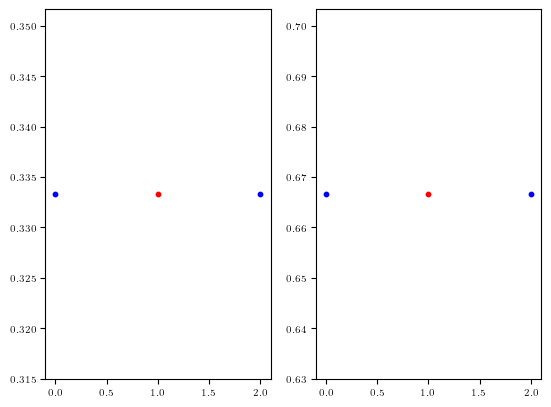

-12.0 -12.0 1 phonon


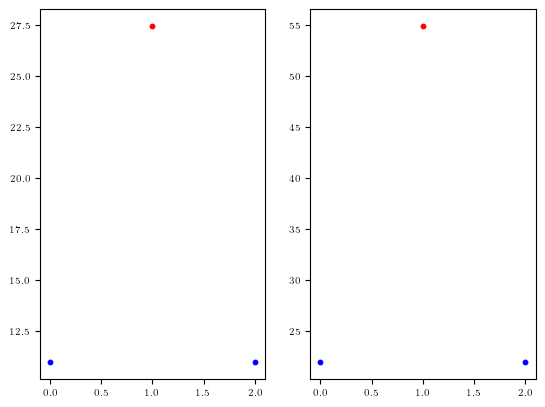

-12.0 -12.0 1 phonon


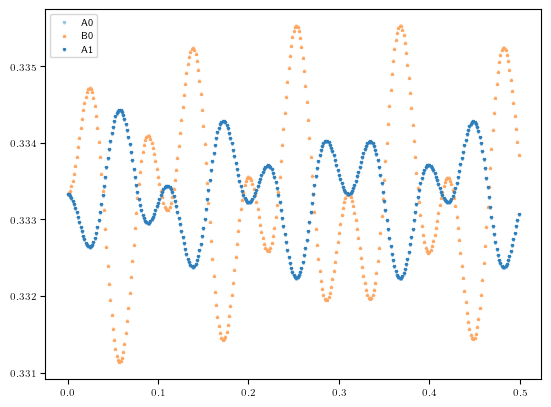

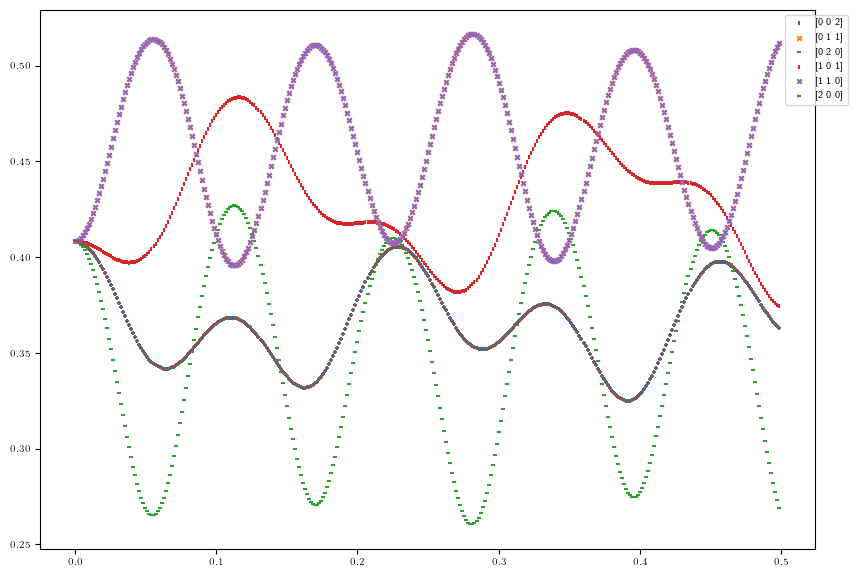

In [ ]:
for l in range(2,8):
    excit_phonons = l
    excit_spin = 1
    chain_length = 3
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    atol = 1e-16
    b=a/2
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*a
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*a + b*np.array([1,0])+h*np.array([0,1])
    dims_phonon = [excit_phonons+1]*chain_length
    dims_spin = [excit_spin+1]*chain_length

    ind = project_indices(excit_phonons,chain_length)  
    ind_spin = project_indices(excit_spin,chain_length)

    state_sp =0
    b0 = 1.6
    # d = np.array([np.sqrt(1/3),np.sqrt(2/3)])
    d = np.array([0,1])
    eig0 = np.zeros(chain_length)
    eig0[:] = 1
    for i in range(chain_length):
        state_sp += project_vec(ind_spin,enr_fock([2]*chain_length,1,[1 if n==i else 0 for n in range(chain_length)]))* eig0[i]

    # vecph = np.zeros(int(factorial(chain_length+excit_phonons-1)/(factorial(excit_phonons)*factorial(chain_length-1)))) 
    # vecph[2] = 1

    # state_ph = Qobj(csr_matrix(vecph)).dag()
    # state_ph = project_vec(ind,enr_fock(chain_length*[excit_phonons+1],excit_phonons,[excit_phonons if j==1 else 0 for j in range(chain_length)]))
    state_ph = Qobj(csr_matrix(np.ones(int(factorial(chain_length+excit_phonons-1)/(factorial(excit_phonons)*factorial(chain_length-1)))))).dag()
    state0 = tensor(state_sp,state_ph)

    psiq = state0.unit()

    S= system(chain_length,excit_phonons,dip_dip,dip_derivative_full,a=2,full=False,ph_scale=1, d= d)
    
    # psiq = S.Hamiltonian(a/2,0) @ state0.unit()#.dag()
    # tsteps = 7/5*100*excit_phonons-40
    # dt = 400/tsteps
    tsteps = 200+300/4*excit_phonons
    dt = 0.5/tsteps
    # print("thermal_phonons/traj_chain_length4_excite{:d}_time{:.2f}".format(excit_phonons,0.23))
    # return
    t = np.arange(tsteps)*dt
    freq = 1/t[-1]
    S.projectors_eval[0], psiq
    def time_traj(t):
        b = a/2+(b0-a/2)*np.cos(2*np.pi*freq*t)
        Delta = np.sin(2*np.pi*freq*t)
        return b, h, Delta
    S.param_trajectory = time_traj
    fig, ax = plt.subplots(1,2)

    ax[0].scatter(latticeA[0,:],[expect(S.projectors_eval[2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
    ax[0].scatter(latticeB[0,:],[expect(S.projectors_eval[2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)

    ax[1].scatter(latticeA[0,:],[expect(S.projectors_eval[chain_length+2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
    ax[1].scatter(latticeB[0,:],[expect(S.projectors_eval[chain_length+2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)
    plt.show()

    psiq = S.Hamiltonian(a/2,0) @ state0.unit()#.dag()
    fig, ax = plt.subplots(1,2)

    ax[0].scatter(latticeA[0,:],[expect(S.projectors_eval[2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
    ax[0].scatter(latticeB[0,:],[expect(S.projectors_eval[2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)

    ax[1].scatter(latticeA[0,:],[expect(S.projectors_eval[chain_length+2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
    ax[1].scatter(latticeB[0,:],[expect(S.projectors_eval[chain_length+2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)
    plt.show()
    # break
    psiq = state0.unit()#.dag()
    # traj = sesolve(S.Hamiltonian_time,psiq,t,e_ops=S.projectors_eval,options={"atol":atol,"rtol":atol})
    traj = sesolve(S.Hamiltonian(a/2,0),psiq,t,e_ops=S.projectors_eval,options={"store_final_state":True,"atol":atol,"rtol":atol,"store_states":True})
    # t = t[:20],"store_states":True
    # print("size Hamiltonian: ",S.Hamiltonian(b,h).full().shape)
    fig, ax = plt.subplots(1,1)
    fig2, ax2 = plt.subplots(1,1, figsize=(10,7))
    state_number = int(factorial(chain_length+excit_phonons-1)/(factorial(excit_phonons)*factorial(chain_length-1)))
    traj_states = np.zeros((int(tsteps),state_number))
    for j in range(int(tsteps)):
        for i in range(state_number):
            traj_states[j,i] = np.sqrt(np.sum(np.abs(traj.states[j].full()[i::state_number,0])**2))
    marker = ["|","x","_"]
    phonon_states = thermal_phonon_generator(2,chain_length)
    for i in range(state_number):
            ax2.scatter(t,traj_states[:,i],s=10,label=phonon_states[i],marker=marker[i%3])
            # ax2.scatter(t,traj.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    
        # ax2.scatter(t,traj.expect[chain_length+2*i]-traj1.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
        # ax2.scatter(t,traj.expect[chain_length+2*i+1]-traj1.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
        # ax.scatter(t,traj.expect[2*i]-traj1.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
        # ax.scatter(t,traj.expect[2*i+1]-traj1.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
        # ax2.scatter(t,traj.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
        # ax2.scatter(t,traj.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")

    for i in range(chain_length//2+chain_length%2):    
        ax.scatter(t,traj.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}',marker="1")
        if 2*i+1 < chain_length:
            ax.scatter(t,traj.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}",marker="2")
    # ax.scatter(t,traj.expect[chain_length-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
    # ax2.scatter(t,traj.expect[chain_length*2-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
    ax.legend()
    ax2.legend(bbox_to_anchor=(1.05, 1))
    plt.show()
    break

In [ ]:
1/np.sqrt(10)

np.float64(0.31622776601683794)

In [ ]:
factorial(chain_length+excit_phonons-1)/(factorial(excit_phonons)*factorial(chain_length-1)), excit_phonons, 10*np.sqrt(2)

(np.float64(10.0), 2, np.float64(14.142135623730951))

In [ ]:
import os
import re
trajects = []
excitation_n = []
times = []
dirname = "thermal_phonons/chainlength6/"
for filename in os.listdir(dirname):#/chainlength6
    if filename.endswith('.npy'):
        r = re.search("excite[0-9]+", filename)
        if r:
            excitation_n.append(int(r.group(0).lstrip("excite")))
            trajects.append([0, 0])
            times.append([0, 0])
            trajects[-1][1] = np.load(os.path.join(dirname, filename))
            steps = trajects[-1][1].shape[1]
            times[-1][1] = np.arange(steps) * 400 / steps
            trajects[-1][0] = excitation_n[-1]
            times[-1][0] = excitation_n[-1]

times = sorted(times,key=lambda x : x[0])
trajects = sorted(trajects,key=lambda x : x[0])

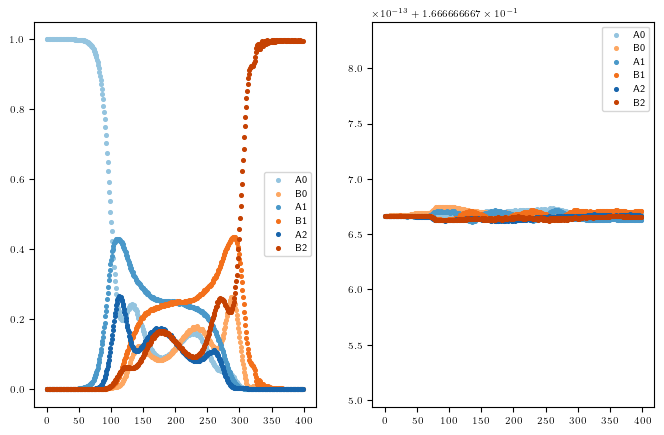

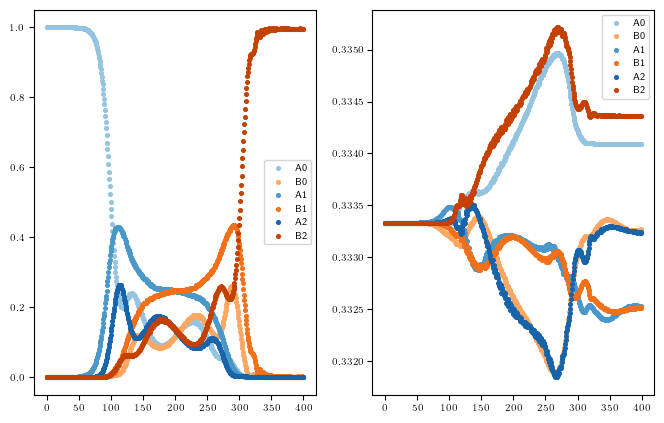

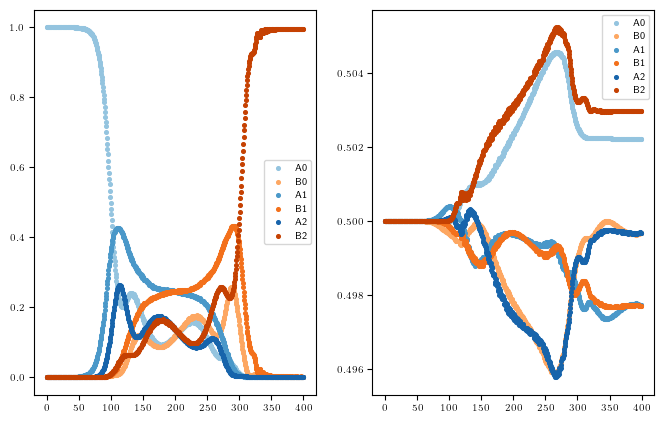

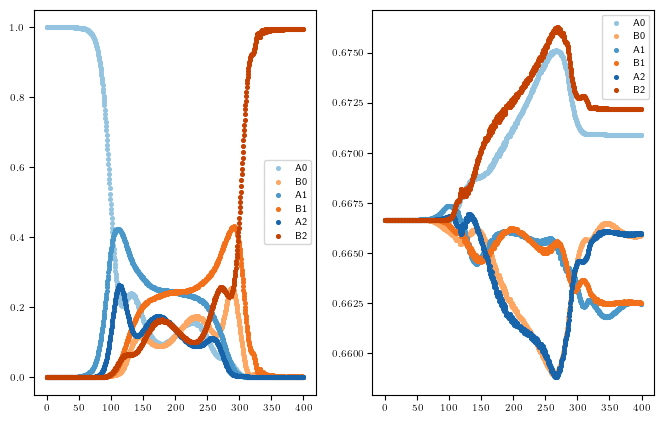

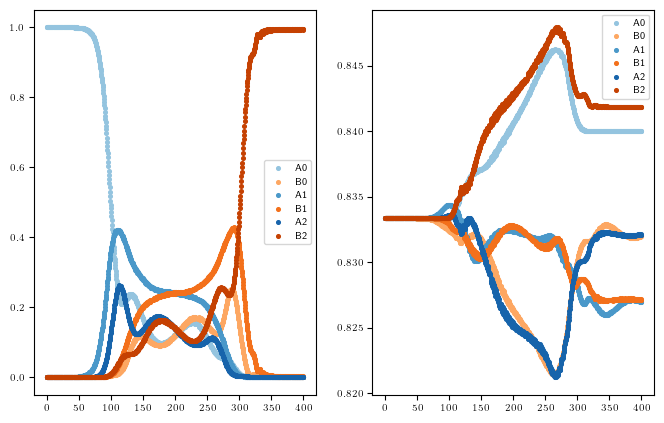

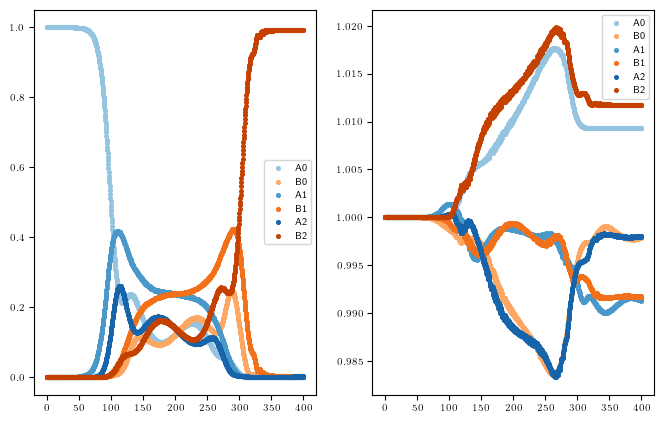

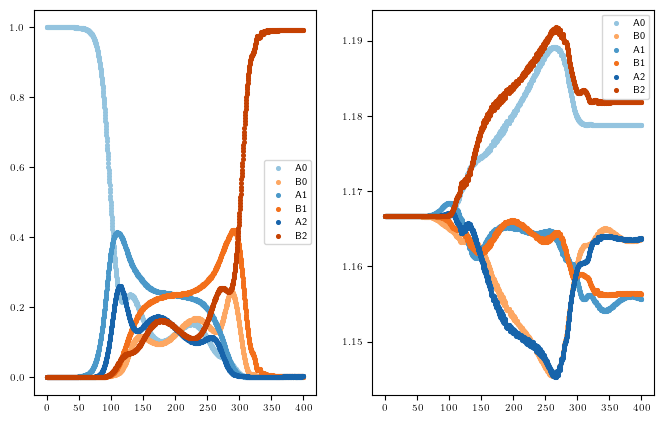

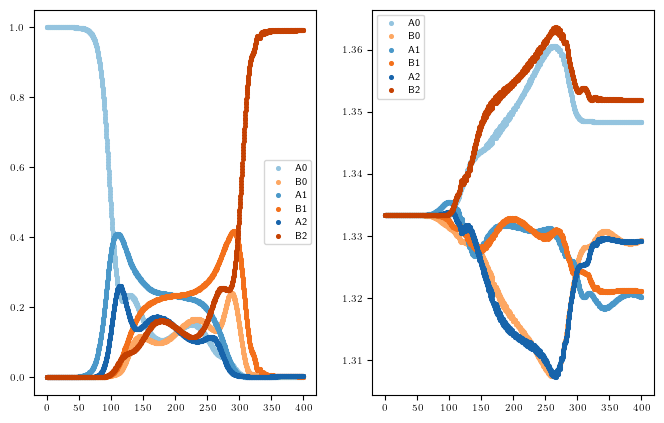

In [ ]:

chain_length=6

for n in range(len(times)):
    fig, ax = plt.subplots(1,2,figsize=(8,5))
    for i in range(chain_length//2):
        ax[1].scatter(times[n][1],trajects[n][1][chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
        ax[1].scatter(times[n][1],trajects[n][1][chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
        ax[0].scatter(times[n][1],trajects[n][1][2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
        ax[0].scatter(times[n][1],trajects[n][1][2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    ax[0].legend()
    ax[1].legend()
    plt.show()

1.0 1.4464400510732622 0.35


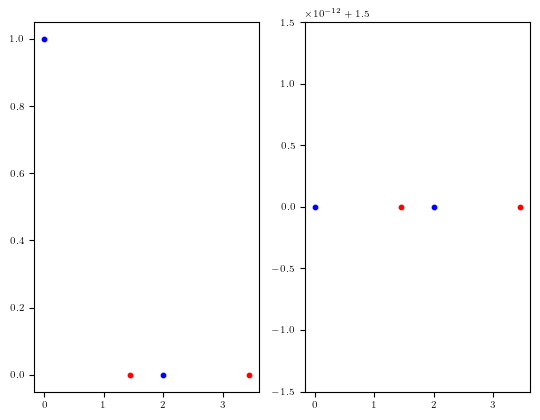

10.0%. Run time:   2.22s. Est. time left: 00:00:00:19
20.0%. Run time:   4.58s. Est. time left: 00:00:00:18
30.0%. Run time:   5.77s. Est. time left: 00:00:00:13
40.1%. Run time:   9.56s. Est. time left: 00:00:00:14
50.1%. Run time:  20.31s. Est. time left: 00:00:00:20
60.1%. Run time:  32.99s. Est. time left: 00:00:00:21
70.1%. Run time:  39.90s. Est. time left: 00:00:00:17
80.1%. Run time:  41.30s. Est. time left: 00:00:00:10
90.1%. Run time:  43.03s. Est. time left: 00:00:00:04
100.0%. Run time:  45.64s. Est. time left: 00:00:00:00
Total run time:  45.64s


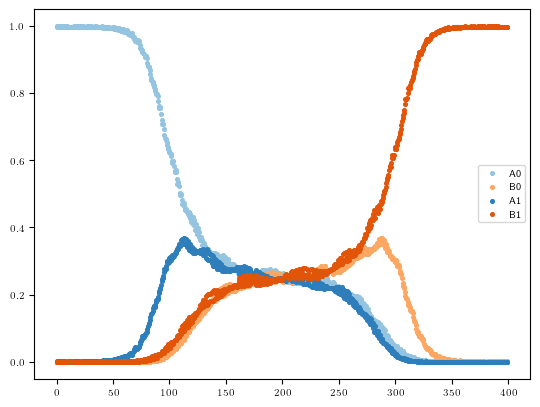

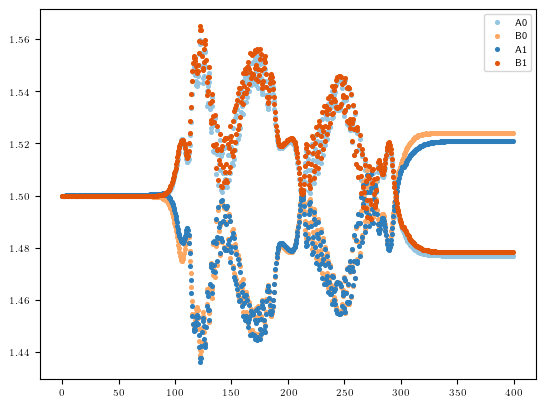

In [ ]:
excit_phonons = 6
excit_spin = 1
chain_length = 4
latticeA = np.zeros((2,chain_length//2+chain_length%2))
latticeB = np.zeros((2,chain_length//2))
atol = 1e-16
for n in range(latticeA.shape[1]):
    latticeA[:,n] = n*np.array([1,0])*a
for n in range(latticeB.shape[1]):
    latticeB[:,n] = n*np.array([1,0])*a + b*np.array([1,0])+h*np.array([0,1])
dims_phonon = [excit_phonons+1]*chain_length
dims_spin = [excit_spin+1]*chain_length

ind = project_indices(excit_phonons,chain_length)  
ind_spin = project_indices(excit_spin,chain_length)
state0 = 0
state_sp =0
b0 = 1.6
d = np.array([np.sqrt(1/3),np.sqrt(2/3)])
dmat = photon_Hamiltonian(b0,h,a,chain_length,dip_dip,0,d)
eig, vec = np.linalg.eig(dmat)
eigen = sort_eigenvalues(eig,vec)
# eig0 = 1/2*(eigen[1,1:]+eigen[1,1:])
# eig0 = eigen[1,1:]
# np.sqrt(2)
eig0 = np.zeros(chain_length)
eig0[0] = 1
for i in range(chain_length):
    # for j in range(chain_length):
        state_sp += project_vec(ind_spin,enr_fock([2]*chain_length,1,[1 if n==i else 0 for n in range(chain_length)]))* eig0[i]
        # state_sp = Qobj(csr_matrix([1 if n==i else 0 for n in range(chain_length)])).dag()# 
        # state_ph = project_vec(ind,enr_fock([excit_phonons+1]*chain_length,excit_phonons,[excit_phonons if n==j else 0 for n in range(chain_length)]))
        # print("qutip: ",enr_fock([3]*chain_length,2,[2 if n==j else 0 for n in range(chain_length)]))
        # state_ph = Qobj(csr_matrix([2 if n==j else 0 for n in range(chain_length)]))
        # print(state_ph)
        # state0 += tensor(state_sp,state_ph) * eig0[i,j]
        # break



# stateph = np.zeros(int(factorial(chain_length+excit_phonons-1)/(factorial(excit_phonons)*factorial(chain_length-1))))
# stateph[5] = 1
# state_ph = Qobj(csr_matrix(stateph)).dag()
state_ph = Qobj(csr_matrix(np.ones(int(factorial(chain_length+excit_phonons-1)/(factorial(excit_phonons)*factorial(chain_length-1)))))).dag()
state0 = tensor(state_sp,state_ph)
# rho1 = state0 * state0.dag()
# psiq = state_sp
psiq = state0.unit()#.dag()
print(psiq.norm(),b,h)   
S= system(chain_length,excit_phonons,dip_dip,dip_derivative_full,a=2,full=False)
# projectors_eval2 = S.project_spin + S.project_phonon
# psiq = tensor(psi0q,eig_generator_ph*phonon0)
#
dt = 0.5
tsteps = 800
t = np.arange(tsteps)*dt
freq = 1/t[-1]
S.projectors_eval[0], psiq
def time_traj(t):
    b = a/2+(b0-a/2)*np.cos(2*np.pi*freq*t)
    Delta = np.sin(2*np.pi*freq*t)
    return b, h, Delta
S.param_trajectory = time_traj
fig, ax = plt.subplots(1,2)
ax[0].scatter(latticeA[0,:],[expect(S.projectors_eval[2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[0].scatter(latticeB[0,:],[expect(S.projectors_eval[2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)

ax[1].scatter(latticeA[0,:],[expect(S.projectors_eval[chain_length+2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[1].scatter(latticeB[0,:],[expect(S.projectors_eval[chain_length+2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)
plt.show()
traj = sesolve(S.Hamiltonian_time,psiq,t,e_ops=S.projectors_eval,options={"progress_bar":True,"store_final_state":True,"atol":atol,"rtol":atol})
# t = t[:20],"store_states":True
# print("size Hamiltonian: ",S.Hamiltonian(b,h).full().shape)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
for i in range(chain_length//2):
    # ax2.scatter(t,traj.expect[chain_length+2*i]-traj1.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    # ax2.scatter(t,traj.expect[chain_length+2*i+1]-traj1.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    # ax.scatter(t,traj.expect[2*i]-traj1.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    # ax.scatter(t,traj.expect[2*i+1]-traj1.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    ax2.scatter(t,traj.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax2.scatter(t,traj.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    ax.scatter(t,traj.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax.scatter(t,traj.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
# ax.scatter(t,traj.expect[chain_length-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
# ax2.scatter(t,traj.expect[chain_length*2-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
ax.legend()
ax2.legend()
plt.show()


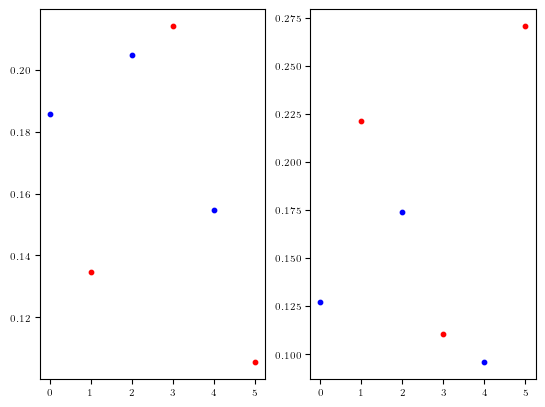

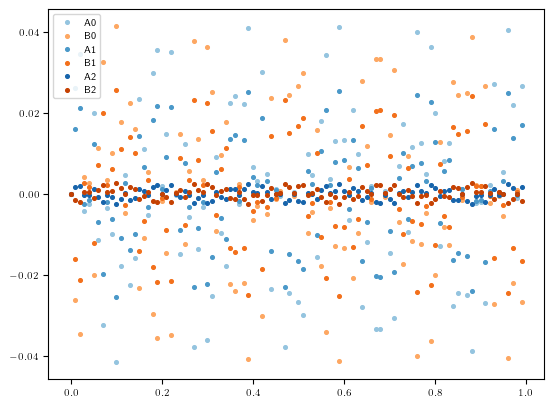

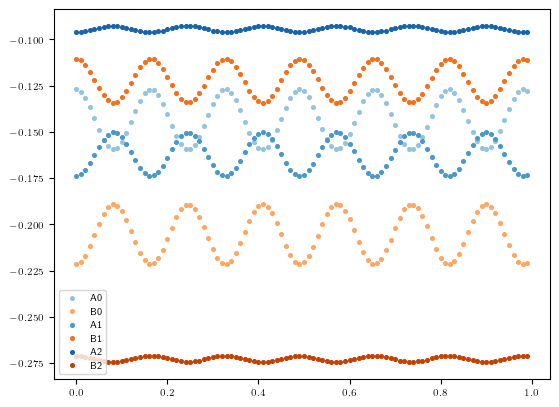

In [ ]:
def Ham_spph_full(b,h,a,d,ph_direction,chain_length,ph_strength,Delta=0):
    latticeA = np.array([[0,0],[a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeA[0]-latticeB
    dist2 = latticeA[1]-latticeB
    inter_ph1 = dip_derivative_full(dist1,ph_direction,ph_direction,d)*ph_strength
    inter_ph2 = dip_derivative_full(dist2,ph_direction,ph_direction,d)*ph_strength
    inter = dip_dip(dist1,d)
    inter2 = dip_dip(dist2,d)
    dmat = np.zeros((chain_length**2,chain_length**2))
    for i in range(chain_length//2):
        for j in range(chain_length):
            dmat[2*i*chain_length+j,(2*i+1)*chain_length+j] += inter
            if i<chain_length//2+chain_length%2-1:
                dmat[(2*i+1)*chain_length+j,2*(i+1)*chain_length+j] += inter2
        for j in range(2):
            dmat[2*i*chain_length+2*i,(2*i+1)*chain_length+2*i+j] += -(-1)**j*inter_ph1
            dmat[2*i*chain_length+2*i+1,(2*i+1)*chain_length+2*i+1-j] += -(-1)**j*inter_ph1
            if i<chain_length//2+chain_length%2-1:
                dmat[(2*i+1)*chain_length+2*i+1,2*(i+1)*chain_length+2*i+1+j] += -(-1)**j*inter_ph2
                dmat[(2*i+1)*chain_length+2*(i+1),2*(i+1)*chain_length+2*(i+1)-j] += -(-1)**j*inter_ph2
    dmat += dmat.T
    if Delta:
        ind = np.arange(chain_length,dtype=np.int16)
        for i in range(chain_length//2):
            
            dmat[ind,ind] = Delta
            ind += chain_length
            dmat[ind,ind] = -Delta
            ind += chain_length
        if chain_length%2:
            dmat[ind,ind] = Delta
    return dmat
# d = np.array([0,1])
# ph_scale = 1/scale_factor
def sintegrate(Ham,t,psi0,time_dependence=False):
    if time_dependence:
        def func(t,psi):
            dpsi = -1j*Ham(t) @ psi
            return dpsi
        def jac(t,psi):
            jacob = -1j*Ham(t)
            return jacob
    else:
        def func(t,psi):
            dpsi = -1j*Ham @ psi
            return dpsi
        def jac(t,psi):
            jacob = -1j*Ham
            return jacob
    r = ode(func,jac).set_integrator('zvode', method='adams',atol=atol,rtol=atol)
    r.set_initial_value(psi0, t[0])
    expect_spin = np.zeros((len(t),chain_length))
    expect_ph = np.zeros((len(t),chain_length))
  
    expect_spin[0,:] = [np.sum(np.abs(psi0[chain_length*j:chain_length*(j+1)])**2) for j in range(chain_length)]
    expect_ph[0,:] = [np.sum(np.abs(psi0[j::chain_length])**2) for j in range(chain_length)]
    
    
    for i,tval in enumerate(t[1:],1):
        r.integrate(tval)
        psi_t = r.y
        expect_spin[i,:] = [np.sum(np.abs(psi_t[chain_length*j:chain_length*(j+1)])**2) for j in range(chain_length)]
        expect_ph[i,:] = [np.sum(np.abs(psi_t[j::chain_length])**2) for j in range(chain_length)]
    
        
    return expect_spin, expect_ph

def stevol(t):
    return Ham_spph_full(b,h,a,d,0,chain_length,ph_scale)
# psi0 = eigenvals0[0,1:]
# psi0 = np.ones(chain_length**2,dtype=np.complex128)/chain_length**2
# psi0[0] =1
psi0 = np.zeros(chain_length**2,dtype=np.complex128)
for i in range(chain_length):
    for j in range(chain_length):
        psi0[i*chain_length+j] = eig0[i,j]


# psi0 = 1/np.sqrt(2)*(eigenvals0[0,1:]+eigenvals0[1,1:])
fig2, ax2 = plt.subplots(1,2)
for j in range(chain_length):
    
    ax2[0].scatter(j,np.sum(np.abs(psi0[chain_length*j:chain_length*(j+1)])**2),color=["blue",'red'][j%2],s=10)
    ax2[1].scatter(j,np.sum(np.abs(psi0[j::chain_length])**2),color=["blue",'red'][j%2],s=10)
plt.show()
traj2 = traj1
expect_spin, expect_ph = sintegrate(stevol(0), t, psi0, time_dependence=False)
# traj = scipy_evolve(stevol(0),  psi0,t)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
for i in range(chain_length//2):
    ax2.scatter(t,expect_ph[:,2*i]-traj2.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax2.scatter(t,expect_ph[:,2*i+1]-traj2.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    ax.scatter(t,expect_spin[:,2*i]-traj2.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax.scatter(t,expect_spin[:,2*i+1]-traj2.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
# ax.scatter(t,expect_spin[:,-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
# ax2.scatter(t,expect_ph[:,-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
ax.legend()
ax2.legend()
plt.show()

1.0 0.38811856294247105 0.2376426429421021


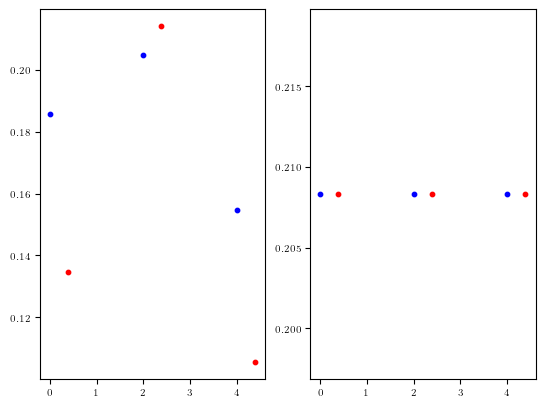

10.1%. Run time:   0.49s. Est. time left: 00:00:00:04
20.2%. Run time:   0.94s. Est. time left: 00:00:00:03
30.3%. Run time:   1.39s. Est. time left: 00:00:00:03
40.4%. Run time:   1.84s. Est. time left: 00:00:00:02
50.5%. Run time:   2.28s. Est. time left: 00:00:00:02
60.6%. Run time:   2.73s. Est. time left: 00:00:00:01
70.7%. Run time:   3.18s. Est. time left: 00:00:00:01
80.8%. Run time:   3.62s. Est. time left: 00:00:00:00
90.9%. Run time:   4.05s. Est. time left: 00:00:00:00
100.0%. Run time:   4.45s. Est. time left: 00:00:00:00
Total run time:   4.45s


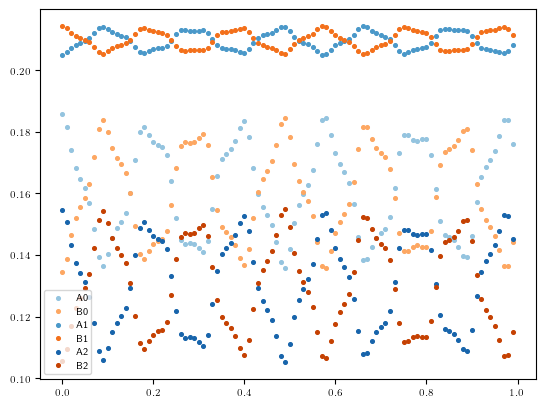

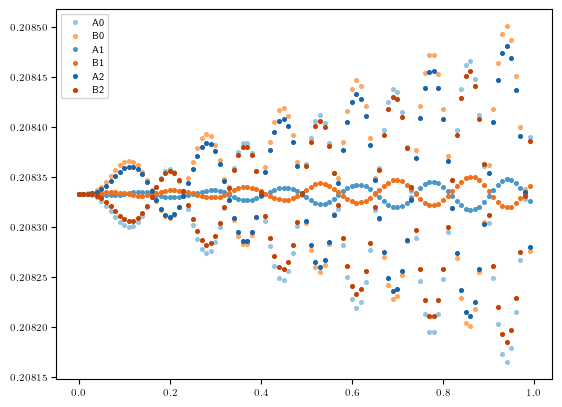

In [ ]:
from qutip import mesolve
state0 = 0
for i in range(chain_length):
    
        state_sp = enr_fock([2]*chain_length,1,[1 if n==i else 0 for n in range(chain_length)])
        
        state0 += state_sp * np.sqrt(np.sum(eig0[i,:]**2))

psiq = state0.unit()#.dag()
rho_sp = psiq * psiq.dag()

excit_phonons = 2#2*chain_length
excit_spin = 1

dims_phonon = [excit_phonons+1]*chain_length
dims_spin = [excit_spin+1]*chain_length

rho0 = tensor(rho_sp,enr_thermal_dm(dims_phonon,excit_phonons,n=0.5))
print(psiq.norm(),b,h)   
S= system(chain_length,excit_phonons,dip_dip,dip_derivative_full,a=2)
projectors_eval2 = S.project_spin + S.project_phonon
# psiq = tensor(psi0q,eig_generator_ph*phonon0)
#
projectors_eval2[1], psiq
wrapper = lambda x : np.abs(x)
fig, ax = plt.subplots(1,2)
ax[0].scatter(latticeA[0,:],[wrapper(S.eval_functions[2*i](0,rho0)) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[0].scatter(latticeB[0,:],[wrapper(S.eval_functions[2*i+1](0,rho0)) for i in range(chain_length//2)],color='red',s=10)

ax[1].scatter(latticeA[0,:],[wrapper(S.eval_functions[chain_length+2*i](0,rho0)) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[1].scatter(latticeB[0,:],[wrapper(S.eval_functions[chain_length+2*i+1](0,rho0)) for i in range(chain_length//2)],color='red',s=10)
plt.show()
traj = mesolve(S.Hamiltonian(b,h),rho0,t,e_ops=S.projectors_eval,options={"progress_bar":True,"store_final_state":True,"atol":atol,"rtol":atol})
# t = t[:20],"store_states":True
# print("size Hamiltonian: ",S.Hamiltonian(b,h).full().shape)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
for i in range(chain_length//2):
    # ax2.scatter(t,traj.expect[chain_length+2*i]-traj1.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    # ax2.scatter(t,traj.expect[chain_length+2*i+1]-traj1.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    # ax.scatter(t,traj.expect[2*i]-traj1.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    # ax.scatter(t,traj.expect[2*i+1]-traj1.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    ax2.scatter(t,traj.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax2.scatter(t,traj.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    ax.scatter(t,traj.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax.scatter(t,traj.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")

    # ax.scatter(t,traj.expect[chain_length-1],co lor=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
# ax2.scatter(t,traj.expect[chain_length*2-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
ax.legend()
ax2.legend()
plt.show()


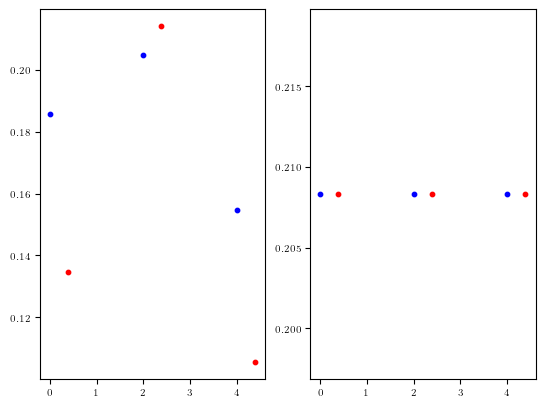

<class 'scipy.sparse._csr.csr_array'> (38416, 1)


TypeError: must be real number, not coo_matrix

In [ ]:
from scipy.sparse import csr_matrix, kron, identity, csr_array
from scipy.integrate import BDF, solve_ivp
def vectorize(mat):
    mat = mat.tocoo()
    return csr_array(mat.reshape(mat.shape[0]**2,1))

def mintegrate(Ham,t,psi0,eval_projectors,time_dependence=False):
    dim = Ham(0).shape[0] if time_dependence else Ham.shape[0]
    identity_H = identity(dim,format='csr')
    evalp = []
    for proj in eval_projectors:
        evalp.append(kron(identity_H,proj,format="csr"))

    
    if time_dependence:
        def func(t,psi):
            sHam = kron(identity_H,Ham(t))-kron(Ham(t).conj(),identity_H,format='csr')
            dpsi = -1j*sHam @ psi
            return dpsi
        def jac(t,psi):
            sHam = kron(identity_H,Ham(t))-kron(Ham(t).conj(),identity_H,format='csr')
            jacob = -1j*sHam
            return jacob
    else:
        sHam = kron(identity_H,Ham)-kron(Ham.conj(),identity_H,format='csr')
        def func(t,psi):
            dpsi = -1j*sHam @ psi
            return dpsi
        def jac(t,psi):
            jacob = -1j*sHam
            return jacob
    
    print(type(psi0),psi0.shape)

    # r = BDF(func,t0=0,y0=psi0,jac=jac,t_bound=t[-1],atol=atol,rtol=atol)
    r = ode(func,jac).set_integrator('zvode', method='adams',atol=atol,rtol=atol)
    psi0 = coo_matrix(([0],[[0],[0]]),shape=(dim**2,1))
    r.set_initial_value(psi0, t[0])
    # solution = solve_ivp(func, (t[0], t[-1]), psi0, method='BDF', jac=jac, t_eval=t, atol=atol, rtol=atol)
    # return solution
    
    return r
    expectation = np.zeros((len(t),chain_length*2))

    identity_tot = vectorize(identity_H).transpose()
    expectation[0,:] = [identity_tot.dot(evalp[j]@psi0).real.astype(np.float64)[0,0] for j in range(chain_length*2)]
  
    
    
    for i,tval in enumerate(t[1:],1):
        r.integrate(tval)
        psi_t = r.y
        expectation[i,:] = [identity_tot.dot(evalp[j]@psi_t).real.astype(np.float64)[0,0] for j in range(chain_length*2)]
      
    
        
    return expectation

rho_vec = vectorize(rho0.to("CSR").data_as("csr_matrix"))
Ham = S.Hamiltonian(b,h).to("CSR").data_as("csr_matrix")
dim = Ham.shape[0]
identity_H = identity(dim,format='csr')
identity_tot = vectorize(identity_H).transpose()
evalp = []
for proj in S.projectors_eval:
    evalp.append(kron(identity_H,proj.to("CSR").data_as("csr_matrix"),format="csr"))

identity_tot.dot(evalp[2*i]@rho_vec).real.astype(np.float64)[0,0]
fig, ax = plt.subplots(1,2)
ax[0].scatter(latticeA[0,:],[identity_tot.dot(evalp[2*i]@rho_vec).real.astype(np.float64)[0,0] for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[0].scatter(latticeB[0,:],[identity_tot.dot(evalp[2*i+1]@rho_vec).real.astype(np.float64)[0,0] for i in range(chain_length//2)],color='red',s=10)

ax[1].scatter(latticeA[0,:],[identity_tot.dot(evalp[chain_length+2*i]@rho_vec).real.astype(np.float64)[0,0] for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[1].scatter(latticeB[0,:],[identity_tot.dot(evalp[chain_length+2*i+1]@rho_vec).real.astype(np.float64)[0,0] for i in range(chain_length//2)],color='red',s=10)
plt.show()

traj = mintegrate(S.Hamiltonian(b,h).to("CSR").data_as("csr_matrix"),t,rho_vec,evalp,time_dependence=False)


# fig, ax = plt.subplots(1,1)
# fig2, ax2 = plt.subplots(1,1)
# for i in range(chain_length//2):
#     ax2.scatter(t,traj[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
#     ax2.scatter(t,traj[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
#     ax.scatter(t,traj[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
#     ax.scatter(t,traj[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
# # ax.scatter(t,traj[chain_length-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
# # ax2.scatter(t,traj[chain_length*2-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
# ax.legend()
# ax2.legend()
# plt.show()
